In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

# Визуализацид зориулсан тохиргоо
plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)

# 1. Файл нэрс ба Станц/Бохирдуулагчийн код
STATION_MAP = {
    'Mo': 'Misheel Expo',
    'Rs': 'Baruun 4-n Zam',
    'U3': 'Takhilt',
    'U1': 'Bukhiin Urguu',
    'U2': '100-n Ail',
    'In': 'Tsahilgaan stants',
    'Bg': 'Urgah naran khoroolol',
    'UB-11': 'Khailaast',
    'UB-12': '5-n buudal',
    'UB-13': 'Zaisan',
    'UB-14': 'Sharkhad',
    'UB-15': 'Nalaikh',
    'UB-16': 'Yarmag',
    'Nacha-1': 'Nisekh',
    'Nacha-2': 'Tolgoit',
    'Nacha-3': 'Zuragt',
    'Nacha-4': 'Amgalan',
}

POLLUTANTS_TO_KEEP = ['AP', 'CO', 'NO2', 'NOX', 'NO', 'O3', 'P10', 'P25', 'SO2', 'T', 'WD', 'WS', 'RH', 'Pr', 'Rh']

# FILE ЗАМЫН:  Jupyter Notebook дээрх бодит зам
BASE_PATH = 'C:\\Users\\Dell\\Documents\\Kaggle ML\\Air quaility in Ub\\content\\'

file_names = [
    '2020.01.01-12.31.xlsx',
    '2021.01.01-12.31.xlsx',
    '2022.01.01-12.31.xlsx',
    '2023.01.01-12.31.xlsx',
    '2024.01.01-12.31.xlsx',
    '2026.01.01-2026.05.31.xlsx'
]
# Бүрэн замыг үүсгэх
file_list = [BASE_PATH + name for name in file_names]

all_data = []
df_combined = pd.DataFrame()

# Баганын нэрийг стандартчилах функц
def standardize_columns(col_name):
    # 1. Remove unit information in parentheses
    cleaned_col_name = re.sub(r'\s*\([^)]*\)\s*', '', col_name).strip()
    # 2. Normalize PM25 to P25 early
    cleaned_col_name = cleaned_col_name.replace('PM25', 'P25')
    # 3. Жижиг/том үсгийн алдааг засах
    cleaned_col_name = cleaned_col_name.replace('u2', 'U2').replace('u1', 'U1').replace('Rh_', 'RH_').replace('Ap_', 'AP_')

    # Try to match Pollutant_StationCode pattern
    for pol in POLLUTANTS_TO_KEEP:
        for abbr, station in STATION_MAP.items():
            pattern = rf"^{re.escape(pol)}_{re.escape(abbr)}$"
            if re.match(pattern, cleaned_col_name):
                return f'{pol}_{station}'

    # Check for standalone pollutant/weather parameters
    for pol in POLLUTANTS_TO_KEEP:
        if cleaned_col_name == pol:
            return pol
            
    return cleaned_col_name

##  2. Файл Унших ба Цэвэрлэх 
for file in file_list:
    try:
        # data-г унших
        df = pd.read_excel(file)

        # Эхний багана (Date) нэргүй тул 'date' гэж нэрлэх
        df = df.rename(columns={df.columns[0]: 'date'})

        # Баганын нэрийг стандартчилах
        new_columns = [standardize_columns(col) for col in df.columns]

        # Ensure column names are unique after standardization
        seen_cols = {}
        unique_new_columns = []
        for col_name_std in new_columns:
            if col_name_std in seen_cols:
                seen_cols[col_name_std] += 1
                unique_new_columns.append(f"{col_name_std}_{seen_cols[col_name_std]}")
            else:
                seen_cols[col_name_std] = 0
                unique_new_columns.append(col_name_std)
        df.columns = unique_new_columns

        # Зөвхөн хэрэгтэй бохирдуулагч болон "date" баганыг сонгох
        selected_cols = ['date'] + [col for col in df.columns if any(pol in col for pol in POLLUTANTS_TO_KEEP) and col != 'date']
        df = df[selected_cols]

        all_data.append(df)

    except Exception as e:
        print(f"Файл уншихад алдаа гарлаа {file}: {e}")

## 3. Датаг Нэгтгэх ба Эцсийн Цэвэрлэгээ 
if all_data:
    df_combined = pd.concat(all_data, ignore_index=True)
    print(f"Амжилттай нэгтгэсэн DataFrame-ийн нийт мөрийн тоо: {len(df_combined)}")

    # Огноо/Цагийг Index болгох
    df_combined['date'] = pd.to_datetime(df_combined['date'])
    df_combined = df_combined.set_index('date').sort_index()

    # Convert all relevant columns to numeric
    for col in df_combined.columns:
        if col != 'date' and df_combined[col].dtype != 'datetime64[ns]':
             df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

    # 5 жилийн PM2.5-ийн өдрийн дундаж утгыг тооцох (2020-202:)
    df_analysis = df_combined[df_combined.index.year <= 2026].copy()

    # 2020-2025 онуудын өдрийн дундаж
    df_daily = df_analysis.resample('D').mean()

    # Хоосон утгыг (NaN) нөхөх (Fill Missing Values)
    df_daily = df_daily.interpolate(method='linear', limit=3)

    print("\nЭцсийн өдөр тутмын дата амжилттай боловсруулагдлаа.")
    print(df_daily.head())

else:
    print("Анхаар: Нэгтгэх DataFrame байхгүй байна. Файл унших алдаа гарсан эсэхийг дахин шалгана уу.")
    df_daily = pd.DataFrame()
    



In [2]:
# CSV 

# Экспортлох файлын нэрийг тодорхойлох
output_file_name = 'ulaanbaatar_air_quality_daily_2020_2026.csv'

if 'df_daily' in locals() and not df_daily.empty:
    # index=True гэдэг нь огноог (date) CSV-ийн эхний багана болгон хадгална гэсэн үг.
    df_daily.to_csv(output_file_name, index=True, encoding='utf-8')
    
    print(f"\n '{output_file_name}' нэртэй CSV файл амжилттай экспортлогдлоо.")
    print("Энэ нь таны ажлын хавтас (working directory)-т хадгалагдсан байгаа.")
    print(f"Файлын эхний 5 мөрийг харуулъя:\n{df_daily.head().to_string()}")
else:
    print("df_daily DataFrame хоосон эсвэл олдсонгүй.")


 'ulaanbaatar_air_quality_daily_2020_2026.csv' нэртэй CSV файл амжилттай экспортлогдлоо.
Энэ нь таны ажлын хавтас (working directory)-т хадгалагдсан байгаа.
Файлын эхний 5 мөрийг харуулъя:
            AP_Misheel Expo  CO_Misheel Expo  HCT_Mo  NO2_Misheel Expo  NO_Misheel Expo  NOx_Mo  O3_Misheel Expo  P10_Misheel Expo  Pr_Misheel Expo  RH_Misheel Expo  SO2_Misheel Expo  T_Misheel Expo  WD_Misheel Expo  WS_Misheel Expo  AP_Baruun 4-n Zam  CO_Baruun 4-n Zam  NO2_Baruun 4-n Zam  NOX_Baruun 4-n Zam  NO_Baruun 4-n Zam  P10_Baruun 4-n Zam  P25_Baruun 4-n Zam  Pr_Baruun 4-n Zam  RH_Baruun 4-n Zam  SO2_Baruun 4-n Zam  T_Baruun 4-n Zam  WD_Baruun 4-n Zam  WS_Baruun 4-n Zam  AP_Takhilt  CO_Takhilt  NO2_Takhilt  NOX_Takhilt  NO_Takhilt  O3_Takhilt  Pr_Takhilt  RH_Takhilt  SO2_Takhilt      TC_U3  WD_Takhilt  WS_Takhilt  AP_Bukhiin Urguu  CO_Bukhiin Urguu  NO2_Bukhiin Urguu  NO_Bukhiin Urguu  NOx_U1  O3_Bukhiin Urguu  P10_Bukhiin Urguu  P25_Bukhiin Urguu  Pr_Bukhiin Urguu  RH_Bukhiin Urguu  SO2_Bu

In [3]:
import re

#  1. df_daily-г Long Format руу хөрвүүлэх 

# 'date' index-ийг багана болгон буцаах
df_long_format = df_daily.reset_index()

# Бүх бохирдуулагчийн багануудыг (Date-ээс бусад) сонгох
cols_to_melt = [col for col in df_long_format.columns if col != 'date']

# 'date' дээр тулгуурлан, бусад бүх багануудыг нэг мөр болгох
df_melted = df_long_format.melt(
    id_vars=['date'],
    value_vars=cols_to_melt,
    var_name='Pollutant_Station',
    value_name='Concentration'
)

# 2. Pollutant_Station баганыг задлах (Split)

# Баганын нэрийг 'Pollutant' болон 'Station' болгон задлах функц
def split_pollutant_station(col_name):
    # '_' тэмдгээр хуваах
    parts = col_name.split('_', 1) 
    
    pollutant = parts[0]
    station = parts[1] if len(parts) > 1 else 'Overall' # Хэрэв "_" байхгүй бол 'Overall' гэж үзнэ
    
    return pollutant, station

# Шинэ багануудыг үүсгэх
df_melted[['Pollutant', 'Station']] = df_melted['Pollutant_Station'].apply(
    lambda x: pd.Series(split_pollutant_station(x))
)

#3. Pivot (Эргүүлэх) хийж, Бохирдуулагчийг Багана болгох 

# 'Station' болон 'date' дээр тулгуурлан 'Pollutant' утгуудыг багана болгон эргүүлэх
df_final_long = df_melted.pivot_table(
    index=['date', 'Station'],
    columns='Pollutant',
    values='Concentration'
).reset_index()

# Индексийн нэрийг арилгах (Optional, but cleaner)
df_final_long.columns.name = None

# PM25-ийг PM2.5 болгох (Уншихад хялбар болгохын тулд)
df_final_long = df_final_long.rename(columns={'P25': 'PM25', 'P10': 'PM10'})


# 4. Үр дүнг CSV файл болгон экспортлох -

output_file_name_long = 'ulaanbaatar_air_quality_long_format_2020_2026.csv'

if not df_final_long.empty:
    df_final_long.to_csv(output_file_name_long, index=False, encoding='utf-8')
    
    print(f"\n '{output_file_name_long}' нэртэй CSV файл (Урт формат) амжилттай экспортлогдлоо.")
    print("Эцсийн DataFrame-ийн бүтэц:")
    print(df_final_long.head().to_string())
else:
    print("\nУрт формат руу хөрвүүлсэн DataFrame хоосон байна.")


 'ulaanbaatar_air_quality_long_format_2020_2026.csv' нэртэй CSV файл (Урт формат) амжилттай экспортлогдлоо.
Эцсийн DataFrame-ийн бүтэц:
        date         Station          AP        CO  CP25          NO        NO2         NOX        NOx        O3        PM10       PM25  PM1  PM10        Pr  Pre         RH         SO2          T  TC          WD        WS
0 2020-01-01       100-n Ail  871.652174  7.323957   NaN         NaN        NaN         NaN        NaN  2.478261  490.608696        NaN  NaN   NaN  0.002609  NaN  55.043478  314.913043 -19.060870 NaN         NaN       NaN
1 2020-01-01              BG         NaN       NaN   NaN         NaN        NaN         NaN        NaN       NaN         NaN        NaN  NaN   NaN  0.000000  NaN        NaN         NaN -21.213043 NaN         NaN       NaN
2 2020-01-01  Baruun 4-n Zam  873.739130  1.902130   NaN  133.086957  139.73913  343.130435        NaN       NaN  112.130435  77.913043  NaN   NaN  0.000000  NaN  54.130435   77.260870 -19.456522 N

In [4]:
# 0. Өмнөх алхмын df_final_long-ийг үүсгэх хэсэг 
if 'df_daily' in locals():
    df_long_format = df_daily.reset_index()
    cols_to_melt = [col for col in df_long_format.columns if col != 'date']
    df_melted = df_long_format.melt(id_vars=['date'], value_vars=cols_to_melt, var_name='Pollutant_Station', value_name='Concentration')
    
    def split_pollutant_station(col_name):
        parts = col_name.split('_', 1) 
        pollutant = parts[0]
        station = parts[1] if len(parts) > 1 else 'Overall'
        return pollutant, station

    df_melted[['Pollutant', 'Station']] = df_melted['Pollutant_Station'].apply(lambda x: pd.Series(split_pollutant_station(x)))
    df_final_long = df_melted.pivot_table(index=['date', 'Station'], columns='Pollutant', values='Concentration').reset_index()
    df_final_long.columns.name = None
    df_final_long = df_final_long.rename(columns={'P25': 'PM25', 'P10': 'PM10'})
else:
    print("df_daily олдсонгүй! Өгөгдөл унших хэсгээ эхлээд ажиллуулна уу.")



if 'df_final_long' in locals():
    # 1. Жил бүрийн өгөгдлийн хэмжээ
    print(" 1. Жил бүрийн өгөгдлийн хэмжээ")
    for year in range(2020, 2026):
        yearly_data = df_combined[df_combined.index.year == year]
        if not yearly_data.empty:
            print(f"{year} он: {yearly_data.shape[0]} мөр, {yearly_data.shape[1]} багана")

    # 2. Станцуудыг кодлох
    station_labels = {name: i+1 for i, name in enumerate(df_final_long['Station'].unique())}
    df_final_long['Station_Code'] = df_final_long['Station'].map(station_labels)
    print("\n 2. Станцын кодчиллын жишээ")
    print(station_labels)
    

    # 4. Missing Data (Хоосон утга)
    print("\n4. Хоосон утгын шинжилгээ")
    missing_count = df_final_long.isnull().sum()
    missing_percent = (missing_count / len(df_final_long)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percent (%)': missing_percent})
    print(missing_df[missing_df['Missing Count'] > 0])

#fixing duplicate 
# 1. Давхардсан багануудыг арилгах (Хэрэв байгаа бол)
df_final_long = df_final_long.loc[:, ~df_final_long.columns.duplicated()].copy()

# 2. Индексийг бүрэн шинэчилж өвөрмөц болгох (Duplicate Index алдааг засна)
df_final_long = df_final_long.reset_index(drop=True)

# 6. Хамгийн өндөр бохирдолтой станцууд (Robust хувилбар)
pollutants = ['AP', 'CO', 'PM25', 'PM10']
print("\n6. Хамгийн өндөр утга бүртгэгдсэн станцууд")

for pol in pollutants:
    if pol in df_final_long.columns:
        # Хамгийн их утгыг олох (NaN-ийг алгасаж хамгийн эхний индексийг авна)
        max_idx = df_final_long[pol].idxmax()
        
        # .iloc ашиглавал индекс давхардсан байсан ч зөвхөн нэг мөрийг (Series) буцаана
        top_row = df_final_long.iloc[max_idx]
        
        max_val = top_row[pol]
        station_name = top_row['Station']
        # Огноог цэвэрлэж форматлах
        obs_date = pd.to_datetime(top_row['date']).strftime('%Y-%m-%d')
        
        print(f"{pol:4}: {max_val:>8.2f} утга '{station_name}' станцад ({obs_date}) бүртгэгдсэн.")

 1. Жил бүрийн өгөгдлийн хэмжээ
2020 он: 8783 мөр, 200 багана
2021 он: 8784 мөр, 200 багана
2022 он: 8736 мөр, 200 багана
2023 он: 8784 мөр, 200 багана
2024 он: 8784 мөр, 200 багана
2025 он: 7888 мөр, 200 багана

 2. Станцын кодчиллын жишээ
{'100-n Ail': 1, 'BG': 2, 'Baruun 4-n Zam': 3, 'In': 4, 'Misheel Expo': 5, 'Takhilt': 6, 'Tsahilgaan stants': 7, 'U3': 8, 'Urgah naran khoroolol': 9, 'ub12': 10, 'Bukhiin Urguu': 11, 'U1': 12, 'U2': 13, 'NIS': 14, 'TOL': 15, 'AMG': 16, 'MNB': 17, 'U11': 18, 'U13': 19, 'UB11': 20, 'UB13': 21, 'Mo': 22, 'UB14': 23, 'UB15': 24, 'U15': 25, 'U14': 26}

4. Хоосон утгын шинжилгээ
      Missing Count  Percent (%)
AP            31974    67.291018
CO            20634    43.425373
CP25          45933    96.668491
NO            20457    43.052866
NO2           20368    42.865561
NOX           36733    77.306591
NOx           31224    65.712602
O3            29825    62.768331
PM10          31217    65.697870
PM25          28763    60.533294
PM1           45621 

In [5]:
if 'df_final_long' in locals():
    # 3.1 Станц бүр дээрх нийт хэмжилтийн тоо 
    print("\n 3.1 Станц бүрийн нийт өгөгдөлтэй өдрийн тоо")
    station_counts = df_final_long.groupby('Station')['date'].count().sort_values(ascending=False)
    print(station_counts)

    # 3.2 Жил болон Станцаар бүлэглэсэн хэмжилтийн тоо (Хүснэгт хэлбэрээр)
    # Аль станц аль жилүүдэд илүү сайн ажилласныг харуулна
    print("\n3.2 Жил бүр станцуудын ажилласан хоногийн тоо")
    df_final_long['Year'] = df_final_long['date'].dt.year
    yearly_counts = df_final_long.groupby(['Year', 'Station']).size().unstack(fill_value=0)
    print(yearly_counts)

 


 3.1 Станц бүрийн нийт өгөгдөлтэй өдрийн тоо
Station
100-n Ail                2232
Baruun 4-n Zam           2159
Misheel Expo             2159
Bukhiin Urguu            2154
BG                       2139
U1                       2139
Urgah naran khoroolol    2139
U3                       2120
Takhilt                  2120
ub12                     1994
Tsahilgaan stants        1950
UB11                     1914
UB13                     1913
U11                      1912
U13                      1908
TOL                      1901
MNB                      1900
NIS                      1874
In                       1697
AMG                      1620
U2                       1507
UB14                     1369
UB15                     1367
U15                      1331
U14                      1296
Mo                        702
Name: date, dtype: int64

3.2 Жил бүр станцуудын ажилласан хоногийн тоо
Station  100-n Ail  AMG   BG  Baruun 4-n Zam  Bukhiin Urguu   In  MNB  \
Year                 

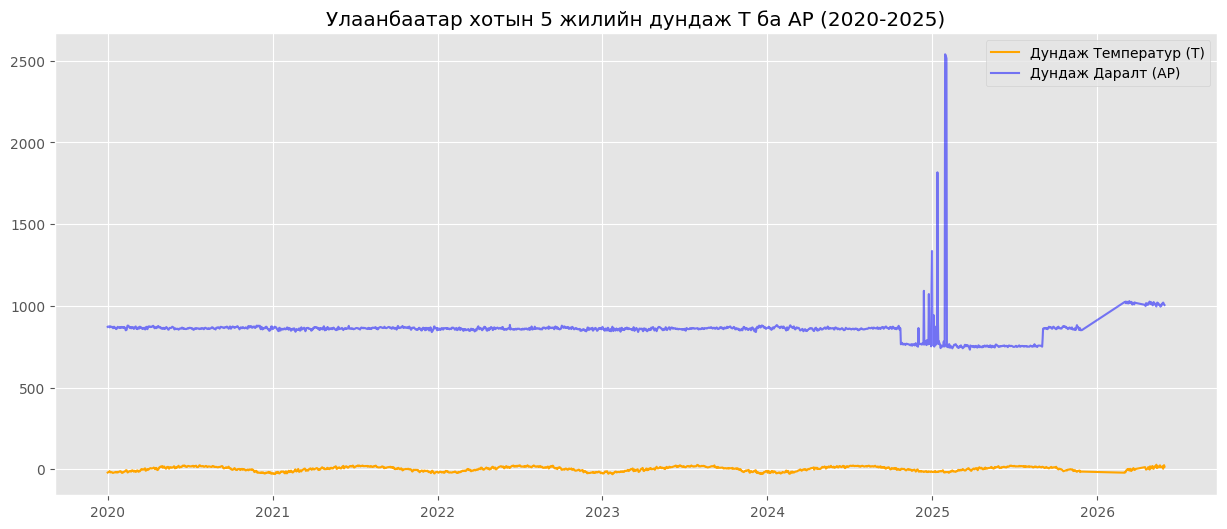

In [6]:
# 5 жилээр өдрийн дундаж (Хотын хэмжээнд)
df_city_avg = df_final_long.groupby('date')[['T', 'AP']].mean()

plt.figure(figsize=(15, 6))
plt.plot(df_city_avg.index, df_city_avg['T'], label='Дундаж Температур (T)', color='orange')
plt.plot(df_city_avg.index, df_city_avg['AP'], label='Дундаж Даралт (AP)', color='blue', alpha=0.5)
plt.title('Улаанбаатар хотын 5 жилийн дундаж T ба AP (2020-2025)')
plt.legend()
plt.show()

In [7]:
#  5. Цаг уурын үзүүлэлтүүдийн хамаарал (Correlation) 
weather_corr = df_final_long[['T', 'WS', 'AP', 'PM25', 'CO']].corr()
print("\n 5. Цаг уур ба Бохирдлын хамаарлын матриц")
print(weather_corr)

#6. Хамгийн өндөр бохирдолтой станцуудыг олох
pollutants = ['AP', 'CO', 'PM25', 'PM10']
print("\n 6. Аль станцад хамгийн өндөр утга бүртгэгдсэн бэ?")

for pol in pollutants:
    if pol in df_final_long.columns:
        max_val = df_final_long[pol].max()
        station_name = df_final_long.loc[df_final_long[pol] == max_val, 'Station'].iloc[0]
        date_val = df_final_long.loc[df_final_long[pol] == max_val, 'date'].iloc[0]
        print(f"{pol}: Хамгийн их {max_val:.2f} утга '{station_name}' станцад ({date_val.date()}) бүртгэгдсэн.")


 5. Цаг уур ба Бохирдлын хамаарлын матриц
             T        WS        AP      PM25        CO
T     1.000000  0.031041  0.030088 -0.435894 -0.494550
WS    0.031041  1.000000  0.053885 -0.032346 -0.202457
AP    0.030088  0.053885  1.000000  0.002525  0.026437
PM25 -0.435894 -0.032346  0.002525  1.000000  0.039505
CO   -0.494550 -0.202457  0.026437  0.039505  1.000000

 6. Аль станцад хамгийн өндөр утга бүртгэгдсэн бэ?
AP: Хамгийн их 16854.25 утга 'Urgah naran khoroolol' станцад (2025-01-29) бүртгэгдсэн.
CO: Хамгийн их 73.44 утга 'Urgah naran khoroolol' станцад (2020-08-30) бүртгэгдсэн.
PM25: Хамгийн их 369568.13 утга 'UB14' станцад (2023-12-23) бүртгэгдсэн.
PM10: Хамгийн их 8337.00 утга 'Bukhiin Urguu' станцад (2024-10-24) бүртгэгдсэн.


12/24

In [8]:
print("\nSee only columns with missing values ≤ 50% ")

missing_count = df_final_long.isnull().sum()
missing_percent = (missing_count / len(df_final_long)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percent (%)': missing_percent
})


# Show only columns with missing values <= 50% (and > 0)
result = missing_df[
    (missing_df['Missing Count'] > 0) &
    (missing_df['Percent (%)'] <= 50)
]

print(result)



See only columns with missing values ≤ 50% 
     Missing Count  Percent (%)
CO           20634    43.425373
NO           20457    43.052866
NO2          20368    42.865561
SO2          20502    43.147571


1.Нөхөхөөс өмнөх утга

In [9]:
df_before_knn = df_final_long.copy()

2.NaN байгаа нэг мөрийг ол

In [10]:
target_cols = ['NO2']

row_index = df_before_knn[df_before_knn['NO2'].isna()].index[0]
row_index

np.int64(0)

3.Нөхөхөөс ӨМНӨХ утга

In [11]:
before = df_before_knn.loc[row_index, target_cols]
before


NO2    NaN
Name: 0, dtype: object

4.Dataset бэлтгэх (X, y)

In [12]:
features = ['T', 'WD', 'WS', 'CO', 'NO', 'SO2', 'Station_Code']
target = 'NO2'

X = df_final_long[features]
y = df_final_long[target]



4.KNN inputer


KNN (K-Nearest Neighbors) нь хоосон утгыг нөхөхдөө бусад багануудын (T, WS, AP г.м) үзүүлэлтээр хамгийн ижил төстэй 5 өдрийг олж, тэдгээр өдрүүдийн дунджийг авч нөхдөг.Зүгээр нэг дундаж тоо тавих биш, тухайн үеийн агаар мандлын нөхцөл байдалд тохирсон "хамгийн боломжит" утгыг олж нөхөж байгаа хэрэг юм.

“KNN Imputation аргыг ашиглан ижил нөхцөлтэй өдрүүдийн утгаар хоосон өгөгдлийг нөхсөн.”


In [13]:
from sklearn.impute import KNNImputer

cols_for_impute = features + [target]  # include NO2

imputer = KNNImputer(n_neighbors=5)

df_imputed_all = pd.DataFrame(
    imputer.fit_transform(df_final_long[cols_for_impute]),
    columns=cols_for_impute,
    index=df_final_long.index
)

# Write imputed NO2 back
df_final_long['NO2'] = df_imputed_all['NO2']

X_imputed = df_imputed_all[features]


5.KNN-ИЙН ДАРАА ХАДГАЛ

In [14]:
df_after_knn = df_final_long.copy()

6.Нөхсөний ДАРААХ утга

In [15]:
after = df_after_knn.loc[row_index, target_cols]
after


NO2    44.375
Name: 0, dtype: object

7.BEFORE / AFTER ХАРЬЦУУЛАЛТ

In [16]:
compare_row = pd.DataFrame({
    'Before (NaN)': before,
    'After (KNN)': after
})

compare_row


,Before (NaN),After (KNN)
NO2,NaN,44.375


Excel файл болгож хадгалах

In [17]:
compare_row.to_excel(
    "KNN_single_row_comparison.xlsx",
    sheet_name="Before_After",
    index=True
)

In [18]:
comparison = pd.DataFrame({
    'date': df_before_knn['date'],  

    'NO2_before': df_before_knn['NO2'],
    'NO2_after':  df_after_knn['NO2'],

})

comparison.to_excel(
    "KNN_NO2_full_before_after.xlsx",
    index=False
)


In [19]:
df_final_long.to_excel("knn_NO2_imputed_result.xlsx", index=False)


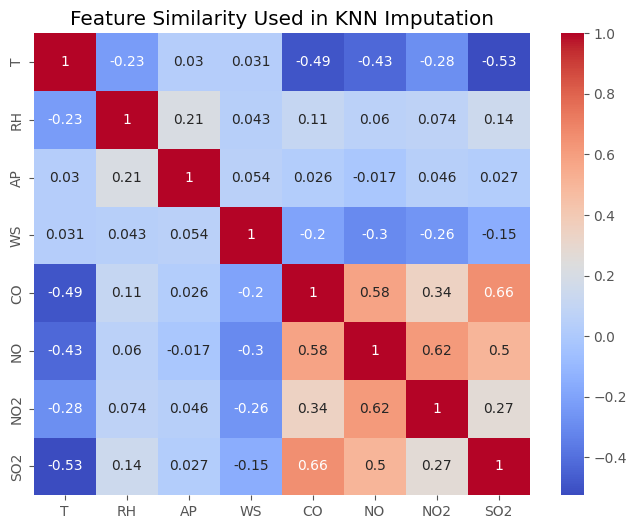

In [20]:
import seaborn as sns

knn_inputs = df_final_long[['T','RH','AP','WS','CO','NO','NO2','SO2']]
corr = knn_inputs.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Similarity Used in KNN Imputation")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8796\1371723258.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('KNN_clean_before_after.png', dpi=150, bbox_inches='tight')


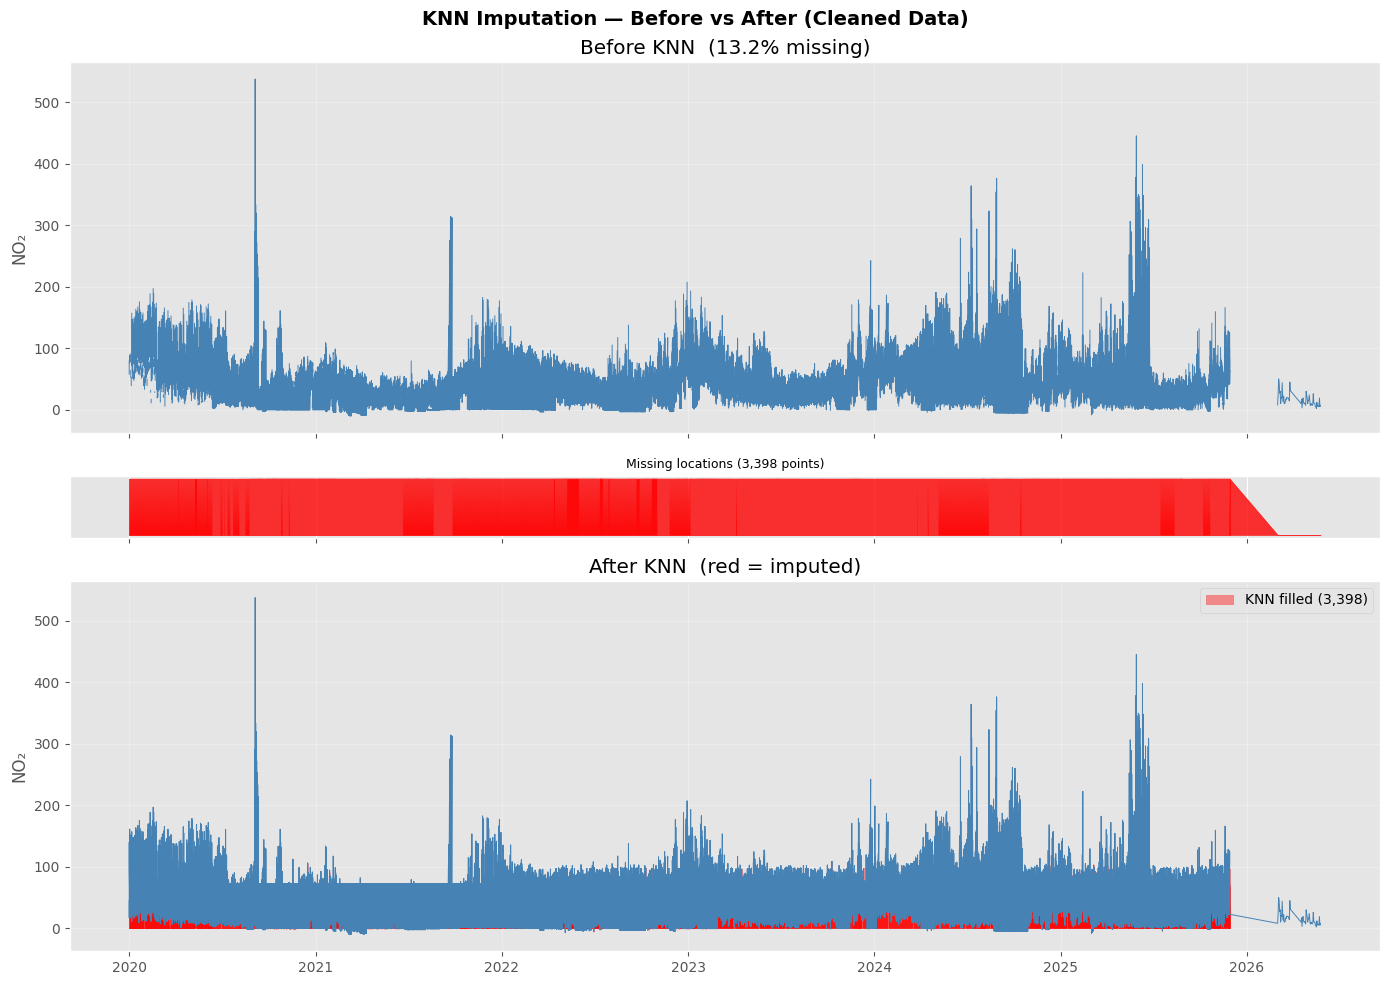

In [21]:
imputed_mask2 = comparison['NO2_before'].isna()  
viz2 = comparison

viz2 = comparison  # энийг plot cell-н өмнө нэм
fig, axes = plt.subplots(3, 1, figsize=(14, 10), 
                          gridspec_kw={'height_ratios': [3, 0.5, 3]}, sharex=True)
fig.suptitle('KNN Imputation — Before vs After (Cleaned Data)', fontsize=14, fontweight='bold')

axes[0].plot(comparison['date'], comparison['NO2_before'], color='steelblue', linewidth=0.7)
axes[0].set_ylabel('NO₂')
axes[0].set_title('Before KNN  (13.2% missing)')
axes[0].grid(alpha=0.3)

axes[1].fill_between(comparison['date'], imputed_mask2.astype(int), color='red', alpha=0.8)
axes[1].set_title(f'Missing locations (3,398 points)', fontsize=9)
axes[1].set_yticks([])

axes[2].plot(comparison['date'], comparison['NO2_after'], color='steelblue', linewidth=0.7)
axes[2].fill_between(comparison['date'], 0, comparison['NO2_after'],
                     where=imputed_mask2, color='red', alpha=0.4, label='KNN filled (3,398)')
axes[2].set_ylabel('NO₂')
axes[2].set_title('After KNN  (red = imputed)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('KNN_clean_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


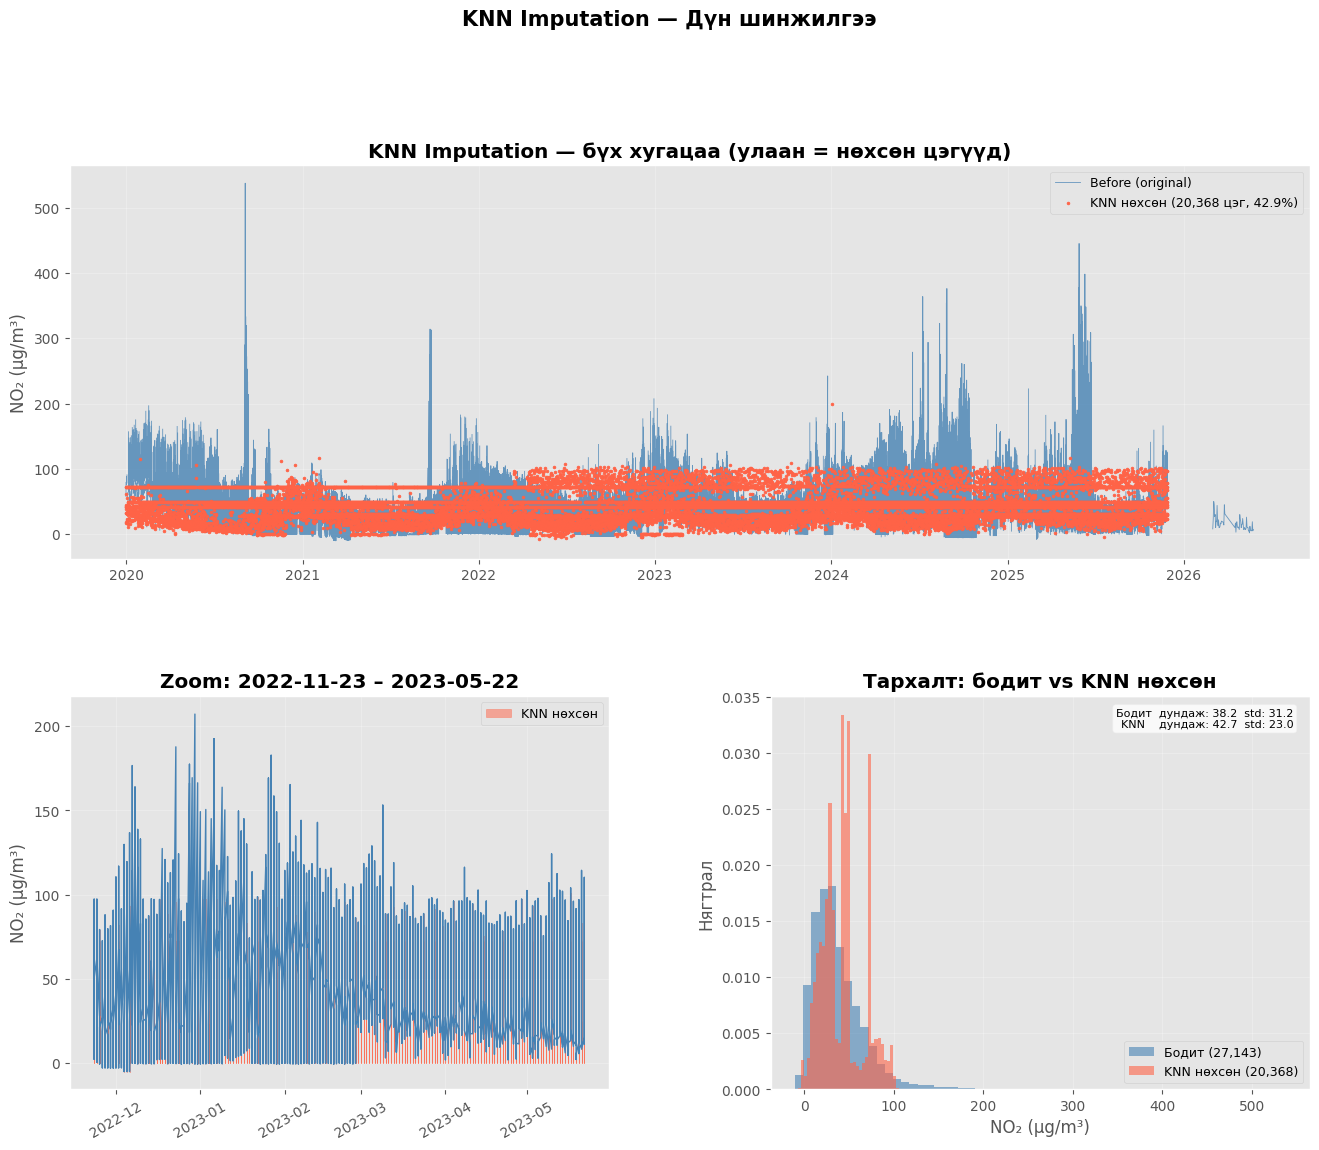

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

imputed_mask2 = comparison['NO2_before'].isna()
n_imputed = imputed_mask2.sum()
pct = n_imputed / len(comparison) * 100

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Дээд зүүн: Before + After нэг дээр (imputed цэгүүд тод)
ax1 = fig.add_subplot(gs[0, :])  # дээд мөр бүтэн өргөн
ax1.plot(comparison['date'], comparison['NO2_before'],
         color='steelblue', linewidth=0.6, label='Before (original)', alpha=0.8)
ax1.scatter(comparison.loc[imputed_mask2, 'date'],
            comparison.loc[imputed_mask2, 'NO2_after'],
            color='tomato', s=4, label=f'KNN нөхсөн ({n_imputed:,} цэг, {pct:.1f}%)', zorder=3)
ax1.set_ylabel('NO₂ (µg/m³)')
ax1.set_title('KNN Imputation — бүх хугацаа (улаан = нөхсөн цэгүүд)', fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.25)

# ── 2. Доод зүүн: Zoom — импутаци ихтэй 1 жилийн хэсэг
ax2 = fig.add_subplot(gs[1, 0])
# Хамгийн олон импутацитай жилийн хэсгийг автоматаар олох
zoom_center = comparison.loc[imputed_mask2, 'date'].median()
zoom_start  = zoom_center - pd.Timedelta(days=90)
zoom_end    = zoom_center + pd.Timedelta(days=90)
mask_zoom   = (comparison['date'] >= zoom_start) & (comparison['date'] <= zoom_end)

ax2.plot(comparison.loc[mask_zoom, 'date'],
         comparison.loc[mask_zoom, 'NO2_after'],
         color='steelblue', linewidth=1)
ax2.fill_between(comparison.loc[mask_zoom, 'date'],
                 0, comparison.loc[mask_zoom, 'NO2_after'],
                 where=imputed_mask2[mask_zoom],
                 color='tomato', alpha=0.5, label='KNN нөхсөн')
ax2.set_ylabel('NO₂ (µg/m³)')
ax2.set_title(f'Zoom: {zoom_start.date()} – {zoom_end.date()}', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
ax2.tick_params(axis='x', rotation=30)

# ── 3. Доод баруун: Тархалтын харьцуулалт (KDE / histogram)
ax3 = fig.add_subplot(gs[1, 1])
original_vals = comparison.loc[~imputed_mask2, 'NO2_after'].dropna()
imputed_vals  = comparison.loc[imputed_mask2,  'NO2_after'].dropna()

ax3.hist(original_vals, bins=60, density=True,
         color='steelblue', alpha=0.6, label=f'Бодит ({len(original_vals):,})')
ax3.hist(imputed_vals,  bins=60, density=True,
         color='tomato',    alpha=0.6, label=f'KNN нөхсөн ({len(imputed_vals):,})')
ax3.set_xlabel('NO₂ (µg/m³)')
ax3.set_ylabel('Нягтрал')
ax3.set_title('Тархалт: бодит vs KNN нөхсөн', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.25)

# Статистик текст
stats = (f"Бодит  дундаж: {original_vals.mean():.1f}  std: {original_vals.std():.1f}\n"
         f"KNN    дундаж: {imputed_vals.mean():.1f}  std: {imputed_vals.std():.1f}")
ax3.text(0.97, 0.97, stats, transform=ax3.transAxes,
         fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('KNN Imputation — Дүн шинжилгээ', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('KNN_imputation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


 Станцуудын координат (ойролцоо утга, бодит map-с авсан)

In [23]:
station_coords = {
    'Misheel Expo': (47.907, 106.952),
    'Baruun 4-n Zam': (47.915, 106.838),
    'Takhilt': (47.926, 106.915),  # Ойролцоо, төв талбайн ойролцоо
    'Bukhiin Urguu': (47.920, 106.860),
    '100-n Ail': (47.912, 106.925),
    'Tsahilgaan stants': (47.930, 106.890),  # Төв
    'Urgah naran khoroolol': (47.885, 106.905),
    'Khailaast': (47.950, 106.920),
    '5-n buudal': (47.895, 106.885),
    'Zaisan': (47.885, 106.935),
    'Sharkhad': (47.955, 106.945),
    'Nalaikh': (47.910, 107.260),  # Хол байрлалтай
    'Yarmag': (47.870, 106.860),
    'Nisekh': (47.940, 106.950),
    'Tolgoit': (47.965, 106.890),
    'Zuragt': (47.930, 106.870),
    'Amgalan': (47.920, 106.980),
}

df_final_long['lat'] = df_final_long['Station'].map(lambda x: station_coords.get(x, (np.nan, np.nan))[0])
df_final_long['lon'] = df_final_long['Station'].map(lambda x: station_coords.get(x, (np.nan, np.nan))[1])

 AQI тооцоолох функц ( NO2-д зориулсан)

In [24]:
def calculate_sub_aqi_no2(c):
    # NO2 1-hour (µg/m³)
    breakpoints = [(0,50,0,54), (51,100,55,100), (101,150,101,360), (151,200,361,649), (201,300,650,1249), (301,500,1250,2049)]
    for low_aqi, high_aqi, low_bp, high_bp in breakpoints:
        if low_bp <= c <= high_bp:
            return ((high_aqi - low_aqi) / (high_bp - low_bp)) * (c - low_bp) + low_aqi
    return 500 if c > 2049 else 0



def calculate_aqi(row):
    aqis = []
    if 'NO2' in row and pd.notna(row['NO2']): aqis.append(calculate_sub_aqi_no2(row['NO2']))
    
    return max(aqis) if aqis else np.nan

# Өдөр тутмын дундаж ашиглан AQI тооцоолох
df_daily_aqi = df_final_long.groupby(['date', 'Station'])[['NO2']].mean().reset_index()
df_daily_aqi['AQI'] = df_daily_aqi.apply(calculate_aqi, axis=1)

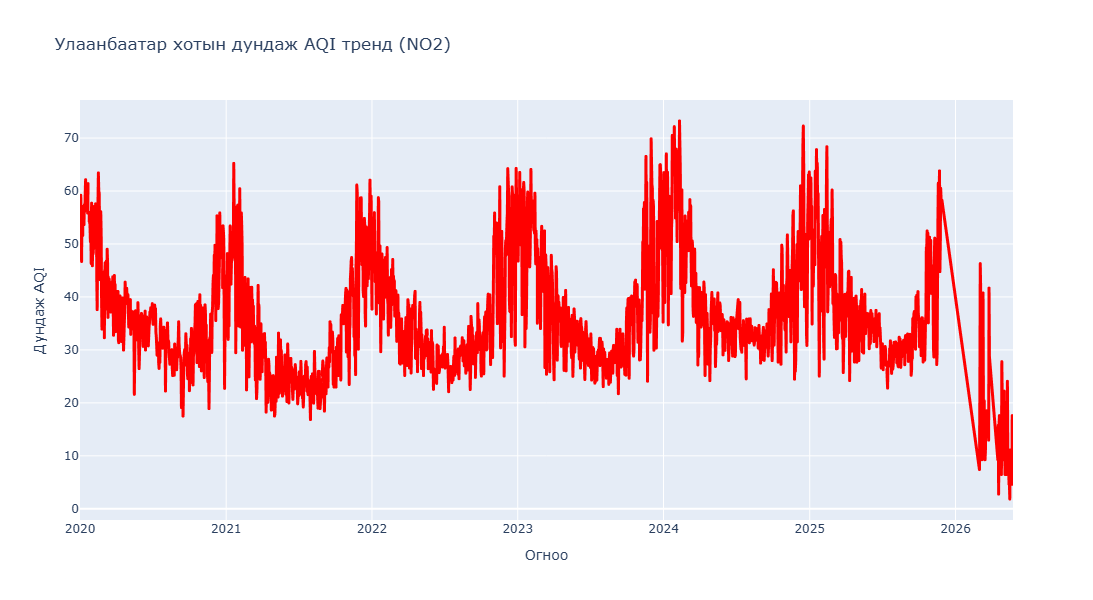

In [25]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Хотын дундаж AQI тренд (хамгийн гол нь энэ – илүү цэвэрхэн харагдана)
df_city_aqi = df_daily_aqi.groupby('date')['AQI'].mean().reset_index()

fig1 = px.line(df_city_aqi, x='date', y='AQI',
               title='Улаанбаатар хотын дундаж AQI тренд (NO2)',
               labels={'date': 'Огноо', 'AQI': 'Дундаж AQI'})
fig1.update_traces(line=dict(width=3, color='red'))
fig1.update_layout(height=600, hovermode='x unified')
fig1.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8796\233670187.py:19: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



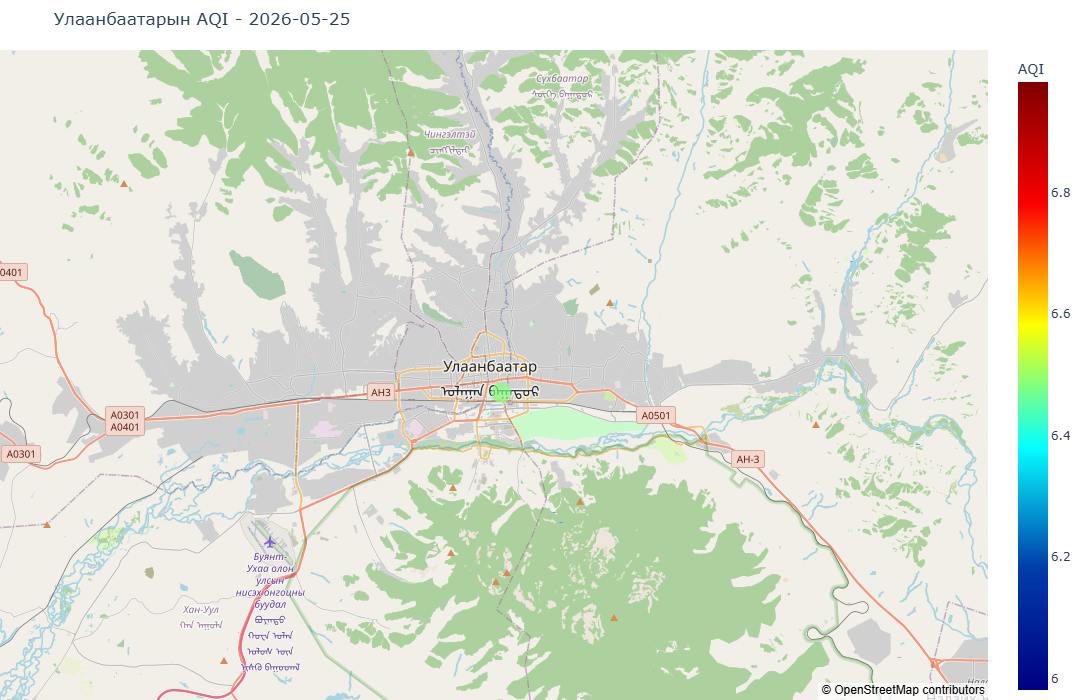

In [26]:
import plotly.express as px
import pandas as pd

# 1. Coords DataFrame
coords_df = pd.DataFrame.from_dict(station_coords, orient='index', 
                                   columns=['lat', 'lon']).reset_index().rename(columns={'index': 'Station'})

# 2. Датагаа бэлдэх
latest_date = df_daily_aqi['date'].max()
df_map = df_daily_aqi[df_daily_aqi['date'] == latest_date].copy()

df_map = df_map.drop(columns=['lat', 'lon'], errors='ignore')
df_map = df_map.merge(coords_df, on='Station', how='left')
df_map = df_map.dropna(subset=['lat', 'lon'])
df_map = df_map.query('47.7 <= lat <= 48.0 and 106.7 <= lon <= 107.3')
df_map['size_val'] = df_map['AQI'].fillna(1).clip(lower=1)

# 3. Зурах
fig = px.scatter_mapbox(
    df_map, lat='lat', lon='lon',
    size='size_val', color='AQI',
    hover_name='Station',
    hover_data={'AQI': ':.2f', 'size_val': False, 'lat': False, 'lon': False},
    color_continuous_scale='Jet',
    size_max=15, zoom=10, height=700, width=1000,
    title=f'Улаанбаатарын AQI - {latest_date.date()}'
)
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox=dict(center=dict(lat=47.92, lon=106.92)),
    margin={"r":0,"t":50,"l":0,"b":0}
)
fig.show()


AQICN (World Air Quality Index) API-д HTTP хүсэлт илгээж

Улаанбаатар хотын бодит цагийн мэдээллийг JSON хэлбэрээр татаж авна.

In [20]:
import requests

API_KEY = "d6a36adb899ff2632ca371b14429e270fa3f41b1"
CITY = "Ulaanbaatar"

url = f"https://api.waqi.info/feed/{CITY}/?token={API_KEY}"
response = requests.get(url).json()

data = response["data"]

today_weather = pd.DataFrame({
    "T": [data["iaqi"].get("t", {}).get("v")],
    "RH": [data["iaqi"].get("h", {}).get("v")],
    "AP": [data["iaqi"].get("p", {}).get("v")],
    "WS": [data["iaqi"].get("w", {}).get("v")],
    "Station_Code": [1]
})

print("Өнөөдрийн бодит цаг уур (API):")
print(today_weather)

Өнөөдрийн бодит цаг уур (API):
    T  RH    AP   WS  Station_Code
0  12  46  1011  4.6             1


Судалгаанд aqicn.org сайтын API ашиглан Улаанбаатар хотын бодит цагийн цаг уурын өгөгдлийг автоматаар татаж авсан. Уг өгөгдлийг сургалтын үед ашигласан стандартчиллын параметрүүдээр хэвийнжүүлж, машин сургалтын загвараар агаарын бохирдуулагч бодисуудын агууламжийг таамагласан. Үр дүнг анхны хэмжих нэгжид буцаан хөрвүүлж, AQI индекс тооцоолон агаарын чанарын түвшинг үнэлсэн

“Оролтын өгөгдлийг стандартчилснаар загварын сургах үр дүнг сайжруулсан.”

In [21]:
# Хамгийн сүүлийн 5 мөрийг харах
print(df_final_long.tail())

            date    Station      AP  CO  CP25  NO   NO2  NOX  NOx  O3  PM10  \
47511 2026-05-26  100-n Ail  1011.0 NaN   NaN NaN   4.0  NaN  NaN NaN   NaN   
47512 2026-05-27  100-n Ail  1020.0 NaN   NaN NaN   4.0  NaN  NaN NaN   NaN   
47513 2026-05-28  100-n Ail  1015.0 NaN   NaN NaN  13.0  NaN  NaN NaN   NaN   
47514 2026-05-29  100-n Ail  1008.0 NaN   NaN NaN  13.0  NaN  NaN NaN   NaN   
47515 2026-05-30  100-n Ail  1005.0 NaN   NaN NaN  17.0  NaN  NaN NaN   NaN   

       PM25  PM1  Pr  Pre    RH  SO2     T  TC  WD  WS  Station_Code  Year  
47511   NaN  NaN NaN  NaN  21.0  NaN  17.0 NaN NaN NaN             1  2026  
47512   NaN  NaN NaN  NaN  12.0  NaN   3.0 NaN NaN NaN             1  2026  
47513   NaN  NaN NaN  NaN  21.0  NaN  20.0 NaN NaN NaN             1  2026  
47514   NaN  NaN NaN  NaN  13.0  NaN  25.0 NaN NaN NaN             1  2026  
47515   NaN  NaN NaN  NaN  31.0  NaN  16.0 NaN NaN NaN             1  2026  


 df_final_long дотор 2026-03-05, NO2=45 байгаа
 Тэр дата train set-д орсон байж болзошгүй → загвар "цээжилсэн"
 Гэтэл predict хийхэд өөр утга гарч байна → overfitting шинж

Scaler тохирохгүй байж болно

3/11

1. Шаардлагатай сангууд болон Feature Engineering

In [22]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Огнооноос нэмэлт feature-ууд үүсгэх (KeyError-оос сэргийлнэ)
df_final_long['month'] = df_final_long['date'].dt.month
df_final_long['day'] = df_final_long['date'].dt.day
df_final_long['weekday'] = df_final_long['date'].dt.weekday

# 2. Сарын дундажийг тооцоолох (Загварын нарийвчлалыг сайжруулна)
monthly_avg = df_final_long[df_final_long['date'].dt.year < 2026].groupby(
    ['month', 'Station'])['NO2'].mean().reset_index()
monthly_avg.columns = ['month', 'Station', 'NO2_monthly_avg']

# Датагаа нэгтгэх
df_ml2 = df_final_long[df_final_long['date'].dt.year < 2026].copy()
df_ml2 = df_ml2.merge(monthly_avg, on=['month', 'Station'], how='left')

# Feature-уудаа тодорхойлох
features_v2 = ['T', 'WS', 'AP', 'RH', 'Station_Code', 'month', 'day', 'weekday', 'NO2_monthly_avg']
target = 'NO2'

df_ml2 = df_ml2.dropna(subset=features_v2 + [target])
X2 = df_ml2[features_v2]
y2 = df_ml2[target]

C:\Users\Dell\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [23]:
# Scaling
scaler_X2 = StandardScaler()
scaler_y2 = StandardScaler()

X_sc = scaler_X2.fit_transform(X2)
y_sc = scaler_y2.fit_transform(y2.values.reshape(-1, 1))

# Загвар үүсгэх
model2 = tf.keras.Sequential([
layers.Dense(128, activation='relu', input_shape=(len(features_v2),)),
layers.Dropout(0.2),
layers.Dense(64, activation='relu'),
layers.Dense(32, activation='relu'),
layers.Dense(1, activation='relu')
])
model2.compile(optimizer='adam', loss='mse', metrics=['mae' ])

# Cyp2ax (Xuwe3 60n20x 50 epoch)
model2.fit(X_sc, y_sc, epochs=50, batch_size=32, verbose=0)
print("Загвар амжилттай сургагдлаа.")

C:\Users\Dell\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Загвар амжилттай сургагдлаа.


In [24]:
# 100-n Ail станцын 5-р сарын туухэн дундаж
march_avg_val = monthly_avg[(monthly_avg['month'] == 5) &
(monthly_avg['Station'] == '100-n Ail')]['NO2_monthly_avg'].values[0]

# Өнөөдрийн өгөгдөл (2026-05-30)
today_data = pd.DataFrame({
'T': [12], 'WS': [4.6], 'AP': [1011], 'RH': [46],
'Station_Code': [1], 'month': [5], 'day': [31], 'weekday': [7], 
'NO2_monthly_avg': [march_avg_val]
})
# Таамаглах
today_sc = scaler_X2.transform(today_data[features_v2])
pred_sc = model2.predict(today_sc)
pred_final = scaler_y2.inverse_transform(pred_sc)

print(f"\n --- Yp дун --- ")
print(f"Таамагласан NO2: {pred_final[0][0]:.2f} ug/m3")
print(f"БОАМТ утга: 6.00 ug/m3")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

 --- Yp дун --- 
Таамагласан NO2: 59.02 ug/m3
БОАМТ утга: 6.00 ug/m3


Сайжруулсан Neural Network (Эцсийн Загвар)


In [25]:

# АЛХАМ 1: Сайжруулсан Feature Engineering (NaN-tolerant)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_imp = df_ml2.copy().sort_values(['Station', 'date'])

print(f"Анхны дата: {len(df_imp)} мөр, column-ууд: {list(df_imp.columns)}")
print(f"Дата давтамж: {df_imp['date'].diff().dt.days.median():.0f} хоног (1=өдөр, 30=сар)")

# Lag features: NaN гарвал monthly_avg-аар орлуулна
for lag in [1, 3, 7]:
    col = f'NO2_lag{lag}'
    df_imp[col] = df_imp.groupby('Station')['NO2'].shift(lag)
    # NaN байвал сарын дундажаар дүүргэ
    df_imp[col] = df_imp[col].fillna(df_imp['NO2_monthly_avg'])

df_imp['NO2_roll7'] = df_imp.groupby('Station')['NO2'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
).fillna(df_imp['NO2_monthly_avg'])

# --- Cyclical encoding ---
df_imp['month_sin'] = np.sin(2 * np.pi * df_imp['month'] / 12)
df_imp['month_cos'] = np.cos(2 * np.pi * df_imp['month'] / 12)
df_imp['wday_sin']  = np.sin(2 * np.pi * df_imp['weekday'] / 7)
df_imp['wday_cos']  = np.cos(2 * np.pi * df_imp['weekday'] / 7)

# Extra features: байгаа бөгөөд NaN < 50% байвал л нэм 
extra_features = []
for col in ['NO', 'NOX', 'WD', 'O3', 'SO2']:
    if col in df_imp.columns:
        null_pct = df_imp[col].isna().mean()
        if null_pct < 0.5:
            df_imp[col] = df_imp[col].fillna(df_imp[col].median())
            extra_features.append(col)
            print(f"+ {col} нэмэгдлээ (NaN: {null_pct:.1%})")
        else:
            print(f"- {col} орхисон (NaN хэт их: {null_pct:.1%})")

features_improved = [
    'T', 'WS', 'AP', 'RH',
    'Station_Code',
    'month_sin', 'month_cos',
    'wday_sin', 'wday_cos',
    'day',
    'NO2_monthly_avg',
    'NO2_lag1', 'NO2_lag3',
    'NO2_lag7', 'NO2_roll7',
] + extra_features

#  Зөвхөн target NaN байвал л мөр устга 
for col in features_improved:
    if df_imp[col].isna().any():
        df_imp[col] = df_imp[col].fillna(df_imp[col].median())

df_imp2 = df_imp.dropna(subset=[target])
X_imp = df_imp2[features_improved]
y_imp = df_imp2[target]

print(f"\nДата хэмжээ: {len(df_imp2)} мөр")
print(f"Feature тоо: {len(features_improved)}")

Анхны дата: 4496 мөр, column-ууд: ['date', 'Station', 'AP', 'CO', 'CP25', 'NO', 'NO2', 'NOX', 'NOx', 'O3', 'PM10', 'PM25', 'PM1', 'Pr', 'Pre', 'RH', 'SO2', 'T', 'TC', 'WD', 'WS', 'Station_Code', 'Year', 'month', 'day', 'weekday', 'NO2_monthly_avg']
Дата давтамж: 1 хоног (1=өдөр, 30=сар)
+ NO нэмэгдлээ (NaN: 6.3%)
- NOX орхисон (NaN хэт их: 52.9%)
+ WD нэмэгдлээ (NaN: 0.0%)
- O3 орхисон (NaN хэт их: 91.1%)
+ SO2 нэмэгдлээ (NaN: 1.4%)

Дата хэмжээ: 4496 мөр
Feature тоо: 18


In [26]:
# АЛХАМ 2: XGBoost загвар сургах ба үнэлэх                     
# XGBoost (Extreme Gradient Boosting) регрессийн аргаар NO2 агаарын
# бохирдлыг таамаглах загвар сургана. Өгөгдлийн хэмжээнээс хамааран
# TimeSeriesSplit хөндлөн шалгалт (CV) эсвэл train/test хуваалт ашиглана.
# Feature-үүд: температур, салхины хурд, даралт, чийглэг, станц, сар,
#   гарагийн sin/cos кодлол, NO2-ийн lag болон rolling дундаж утгууд.
# Гаралт: XGBoost болон хуучин Neural Network загварын MAE, RMSE, R²
#   үзүүлэлтүүд хэвлэгдэж, хоёр загварын сайжруулалтын зөрүү гарна.

try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"X_imp хэмжээ: {len(X_imp)} мөр")

MIN_TEST = 10

if len(X_imp) >= MIN_TEST * 2:
    split_idx = max(int(len(X_imp) * 0.8), len(X_imp) - MIN_TEST)
    X_train = X_imp.iloc[:split_idx]
    X_test  = X_imp.iloc[split_idx:]
    y_train = y_imp.iloc[:split_idx]
    y_test  = y_imp.iloc[split_idx:]
    use_cv  = False
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
else:
    X_train, y_train = X_imp, y_imp
    X_test,  y_test  = X_imp, y_imp
    use_cv = True
    print(f"Дата цөөн ({len(X_imp)} мөр) — Cross-Validation ашиглана")

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

if use_cv or len(X_test) < MIN_TEST:
    n_splits = min(5, len(X_imp) // 2)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_mae = -cross_val_score(xgb_model, X_imp, y_imp,
                               cv=tscv, scoring='neg_mean_absolute_error')
    xgb_model.fit(X_train, y_train)
    print(f"XGBoost CV MAE: {cv_mae.mean():.2f} ± {cv_mae.std():.2f} µg/m³")
    mae_xgb = cv_mae.mean()
    rmse_xgb = np.nan
    r2_xgb   = np.nan
    mae_nn   = mae_xgb
else:
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb   = r2_score(y_test, y_pred_xgb)

    shared_cols = [c for c in features_v2 if c in X_test.columns]
    if len(shared_cols) == len(features_v2):
        y_pred_old = model2.predict(scaler_X2.transform(X_test[features_v2]), verbose=0)
        y_pred_old = scaler_y2.inverse_transform(y_pred_old).flatten()
        mae_nn  = mean_absolute_error(y_test, y_pred_old)
        rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_old))
        r2_nn   = r2_score(y_test, y_pred_old)
    else:
        mae_nn = rmse_nn = r2_nn = np.nan

    print("=" * 45)
    print(f"  XGBoost MAE  : {mae_xgb:.2f} µg/m³")
    print(f"  XGBoost RMSE : {rmse_xgb:.2f} µg/m³")
    print(f"  XGBoost R²   : {r2_xgb:.4f}")
    if not np.isnan(mae_nn):
        print(f"  Хуучин NN MAE: {mae_nn:.2f} µg/m³")
        print(f"  Сайжруулалт  : {mae_nn - mae_xgb:+.2f} µg/m³")

X_imp хэмжээ: 4496 мөр
Train: 4486, Test: 10
  XGBoost MAE  : 14.01 µg/m³
  XGBoost RMSE : 17.75 µg/m³
  XGBoost R²   : 0.6767


In [27]:
# АЛХАМ 3: Сайжруулсан Neural Network загвар сургах            
# TensorFlow/Keras ашиглан 4 давхаргат (256→128→64→32→1) гүн нейрон
# сүлжээг NO2 таамаглалд сургана. BatchNormalization болон Dropout
# давхаргаар хэт тохируулалтаас (overfitting) хамгаална.
# Оновчлогч: Adam (lr=0.001), алдааны функц: Huber loss.
# EarlyStopping (patience=30) болон ReduceLROnPlateau (patience=10)
# callback-үүдээр сургалтыг автоматаар зогсоож, суралцах хурдыг бууруулна.
# Гаралт: зогссон epoch дугаар болон тест дээрх MAE, RMSE, R² үзүүлэлтүүд
#   (эсвэл өгөгдөл цөөн бол validation MAE scaled утга) хэвлэгдэнэ.

import tensorflow as tf
from tensorflow.keras import layers, callbacks

tf.random.set_seed(42)

scaler_X_imp = StandardScaler()
scaler_y_imp = StandardScaler()

X_train_sc = scaler_X_imp.fit_transform(X_train)
y_train_sc = scaler_y_imp.fit_transform(y_train.values.reshape(-1, 1))

has_separate_test = (len(X_test) >= 10 and not use_cv)

if has_separate_test:
    X_val_sc = scaler_X_imp.transform(X_test)
    y_val_sc = scaler_y_imp.transform(y_test.values.reshape(-1, 1))
    val_data  = (X_val_sc, y_val_sc)
    val_split = 0.0
else:
    val_data  = None
    val_split = 0.2

model_improved = tf.keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(len(features_improved),)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='huber',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

history_imp = model_improved.fit(
    X_train_sc, y_train_sc,
    epochs=300,
    batch_size=max(16, len(X_train) // 10),
    validation_data=val_data,
    validation_split=val_split,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

best_epoch = np.argmin(history_imp.history['val_loss']) + 1
print(f"Зогссон epoch: {best_epoch}/300")

if has_separate_test:
    y_pred_imp = scaler_y_imp.inverse_transform(
        model_improved.predict(X_val_sc, verbose=0)
    ).flatten()
    mae_imp  = mean_absolute_error(y_test, y_pred_imp)
    rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_imp))
    r2_imp   = r2_score(y_test, y_pred_imp)
    print(f"Сайжруулсан NN MAE  : {mae_imp:.2f} µg/m³")
    print(f"Сайжруулсан NN RMSE : {rmse_imp:.2f} µg/m³")
    print(f"Сайжруулсан NN R²   : {r2_imp:.4f}")
else:
    val_mae = min(history_imp.history['val_mae'])
    print(f"Validation MAE (scaled): {val_mae:.4f}")

C:\Users\Dell\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Зогссон epoch: 44/300
Сайжруулсан NN MAE  : 15.25 µg/m³
Сайжруулсан NN RMSE : 20.24 µg/m³
Сайжруулсан NN R²   : 0.5795


lag гэдэг нь өмнөх өдрүүдийн утгыг одоогийн таамаглалд оруулах техник.
    Өнөөдөр (3/27) таамаглахад:
  lag1  = 3/26-ны утга  → хамгийн ойр, хамгийн нөлөөтэй
  lag3  = 3/24-ны утга  → 3 хоног өмнө
  lag7  = 3/20-ны утга  → 7 хоног өмнө
  roll7 = 3/20-3/26-ны дундаж → богино хугацааны тренд
Feature importance графикт NO2_lag1 хамгийн дээр байсан нь үүнийг баталж байна — загвар өчигдрийн утгаас хамгийн их суралцдаг

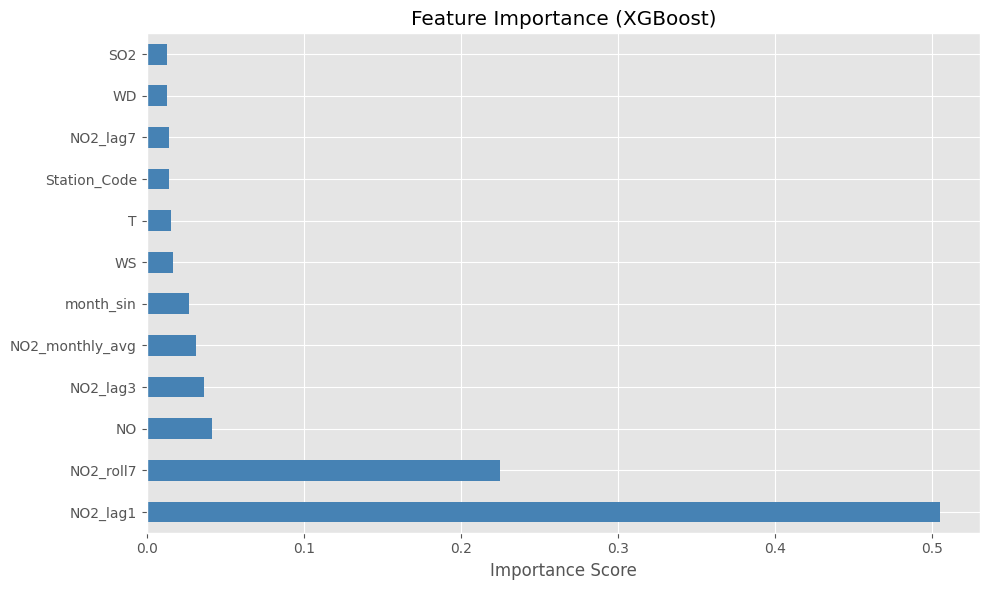

2026 өгөгдлийн сүүлийн 7 хоног:
      date  NO2
2026-05-24  5.0
2026-05-25  7.0
2026-05-26  4.0
2026-05-27  4.0
2026-05-28 13.0
2026-05-29 13.0
2026-05-30 17.0

Нэгтгэсэн dataset-ийн сүүлийн 7 хоног:
      date  NO2
2026-05-24  5.0
2026-05-25  7.0
2026-05-26  4.0
2026-05-27  4.0
2026-05-28 13.0
2026-05-29 13.0
2026-05-30 17.0

lag1=17.00 outlier → roll7=9.00 ашиглана
NO2_monthly_avg = 27.44  (April 2026 proxy)
lag1  = 9.00
lag3  = 13.00
lag7  = 5.00
roll7 = 9.00
NO2_monthly_avg = 27.44
NO    : training mean=35.4  →  2026 prior-month mean=16.7
NOX   : training mean=150.0  →  2026 prior-month mean=52.8
SO2   : training mean=31.1  →  2026 prior-month mean=24.1
WD    : training mean=172.8  →  2026 prior-month mean=191.0

  2026-05-31 NO2 Таамаглал
  Хуучин NN      : 59.02 µg/m³  (алдаа: 53.02)
  Сайжруулсан NN : 9.58 µg/m³  (алдаа: 3.58)
  XGBoost        : 13.33 µg/m³  (алдаа: 7.33)
  Бодит утга     : 6.00 µg/m³


In [28]:
# АЛХАМ 4: Feature Importance + NO2 Таамаглал (2026-05-31)
import matplotlib.pyplot as plt
import numpy as np

# Feature Importance
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=features_improved
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(12).plot(kind='barh', color='steelblue')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# 2026 өгөгдлийг ачаалах 
_xlsx = r'C:\Users\Dell\Documents\Kaggle ML\Air quaility in Ub\content\2026.01.01-2026.05.30.xlsx'
df_2026_raw = pd.read_excel(_xlsx, header=0).iloc[1:].copy()  # row 0 = units
df_2026_raw['date'] = pd.to_datetime(df_2026_raw['date']).dt.normalize()

no2_cols_2026 = [c for c in df_2026_raw.columns if 'no2' in c.lower()]
df_2026_raw[no2_cols_2026] = df_2026_raw[no2_cols_2026].apply(pd.to_numeric, errors='coerce')

df_2026_daily = (
    df_2026_raw.groupby('date')[no2_cols_2026]
    .mean()
    .mean(axis=1)
    .rename('NO2')
    .reset_index()
    .dropna(subset=['NO2'])
)
print(f"2026 өгөгдлийн сүүлийн 7 хоног:\n{df_2026_daily.tail(7).to_string(index=False)}\n")

# Таамаглах огноо
PRED_DATE  = pd.Timestamp('2026-05-31')
PRED_MONTH = PRED_DATE.month
PRED_DAY   = PRED_DATE.day
PRED_WDAY  = PRED_DATE.weekday()

# df_final_long + 2026 нэгтгэх 
recent_base = (
    df_final_long[df_final_long['date'] < PRED_DATE]
    .groupby('date')['NO2'].mean()
    .reset_index()
)
recent = (
    pd.concat([recent_base, df_2026_daily[df_2026_daily['date'] < PRED_DATE]])
    .sort_values('date')
    .drop_duplicates('date', keep='last')
    .dropna(subset=['NO2'])
    .reset_index(drop=True)
)
print(f"Нэгтгэсэн dataset-ийн сүүлийн 7 хоног:\n{recent.tail(7).to_string(index=False)}\n")

def get_closest_no2(df_recent, target_date, fallback):
    candidates = df_recent[df_recent['date'] <= target_date]
    if not candidates.empty:
        return candidates.iloc[-1]['NO2']
    return fallback

#  Lag & roll7 утгууд 
roll7_data = recent.tail(7)['NO2']
roll7 = roll7_data.mean() if not roll7_data.empty else np.nan

lag1 = get_closest_no2(recent, PRED_DATE - pd.Timedelta(days=1), roll7)
lag3 = get_closest_no2(recent, PRED_DATE - pd.Timedelta(days=3), roll7)
lag7 = get_closest_no2(recent, PRED_DATE - pd.Timedelta(days=7), roll7)

if lag1 > roll7 * 1.5:
    print(f"lag1={lag1:.2f} outlier → roll7={roll7:.2f} ашиглана")
    lag1 = roll7

#update
no2_monthly_avg_2026 = df_2026_daily[
    df_2026_daily['date'].dt.month == (PRED_MONTH - 1)  # өмнөх сар
]['NO2'].mean()

# Нэмэлт шалгалт
if pd.isna(no2_monthly_avg_2026):
    no2_monthly_avg_2026 = df_2026_daily['NO2'].mean()  # бүх 2026 дундаж


print(f"NO2_monthly_avg = {no2_monthly_avg_2026:.2f}  (April 2026 proxy)")
#no2_monthly_avg_2026 = df_2026_daily[df_2026_daily['date'].dt.month == PRED_MONTH]['NO2'].mean()
# → (10 + 17 + 3 + 17) / 4 ≈ 11.75  (2026 April өгөгдлөөс)


print(f"lag1  = {lag1:.2f}")
print(f"lag3  = {lag3:.2f}")
print(f"lag7  = {lag7:.2f}")
print(f"roll7 = {roll7:.2f}")
print(f"NO2_monthly_avg = {no2_monthly_avg_2026:.2f}")

#Өнөөдрийн feature-үүд 
today_improved = pd.DataFrame([{
    'T':   12,
    'WS':  4.6,
    'AP':  1011.0,
    'RH':  46.0,
    'Station_Code': 1,
    'month_sin': np.sin(2 * np.pi * PRED_MONTH / 12),
    'month_cos': np.cos(2 * np.pi * PRED_MONTH / 12),
    'wday_sin':  np.sin(2 * np.pi * PRED_WDAY  / 7),
    'wday_cos':  np.cos(2 * np.pi * PRED_WDAY  / 7),
    'day':     PRED_DAY,
    'month':   PRED_MONTH,
    'weekday': PRED_WDAY,
    'NO2_monthly_avg': no2_monthly_avg_2026,
    'NO2_lag1':  lag1,
    'NO2_lag3':  lag3,
    'NO2_lag7':  lag7,
    'NO2_roll7': roll7,
}])

# extra_features-ийн April 2026 дундажийг df_2026_raw-с авах -- build BEFORE use
extra_col_map = {
    'NO':  [c for c in df_2026_raw.columns if c.upper().startswith('NO_') or c.upper() == 'NO'],
    'NOX': [c for c in df_2026_raw.columns if 'NOX' in c.upper() or 'NOx' in c.upper()],
    'SO2': [c for c in df_2026_raw.columns if 'SO2' in c.upper()],
    'WD':  [c for c in df_2026_raw.columns if c.upper().startswith('WD') or 'WD_' in c.upper()],
}

prev_month = PRED_MONTH - 1
prev_month_2026 = df_2026_raw[df_2026_raw['date'].dt.month == prev_month].copy()
if prev_month_2026.empty:
    prev_month_2026 = df_2026_raw.copy()  # бүх 2026 дата fallback
extra_2026_means = {}
for feat, cols in extra_col_map.items():
    vals = prev_month_2026[cols].apply(pd.to_numeric, errors='coerce')
    extra_2026_means[feat] = vals.stack().mean()
    print(f"{feat:6s}: training mean={df_imp[feat].mean():.1f}  →  2026 prior-month mean={extra_2026_means[feat]:.1f}")

# Fill any extra features not already in today_improved
for col in extra_features:
    if col not in today_improved.columns:
        today_improved[col] = extra_2026_means.get(col, df_imp[col].mean())


today_xgb = today_improved[features_improved]
today_old = today_improved[features_v2]

# Таамаглал 
pred_xgb    = max(xgb_model.predict(today_xgb)[0], 0)
pred_old    = max(scaler_y2.inverse_transform(
    model2.predict(scaler_X2.transform(today_old), verbose=0)
)[0][0], 0)

_raw_nn = scaler_y_imp.inverse_transform(
    model_improved.predict(scaler_X_imp.transform(today_xgb), verbose=0)
)[0][0]
if _raw_nn < 0:
    print(f"  [!] Improved NN raw={_raw_nn:.2f} (сөрөг) → 0-д хязгаарлана")
pred_nn_imp = max(_raw_nn, 0)

actual = 6.0

print("\n" + "=" * 52)
print(f"  {PRED_DATE.date()} NO2 Таамаглал")
print("=" * 52)
if actual is not None:
    print(f"  Хуучин NN      : {pred_old:.2f} µg/m³  (алдаа: {abs(pred_old - actual):.2f})")
    print(f"  Сайжруулсан NN : {pred_nn_imp:.2f} µg/m³  (алдаа: {abs(pred_nn_imp - actual):.2f})")
    print(f"  XGBoost        : {pred_xgb:.2f} µg/m³  (алдаа: {abs(pred_xgb - actual):.2f})")
    print(f"  Бодит утга     : {actual:.2f} µg/m³")
print("=" * 52)

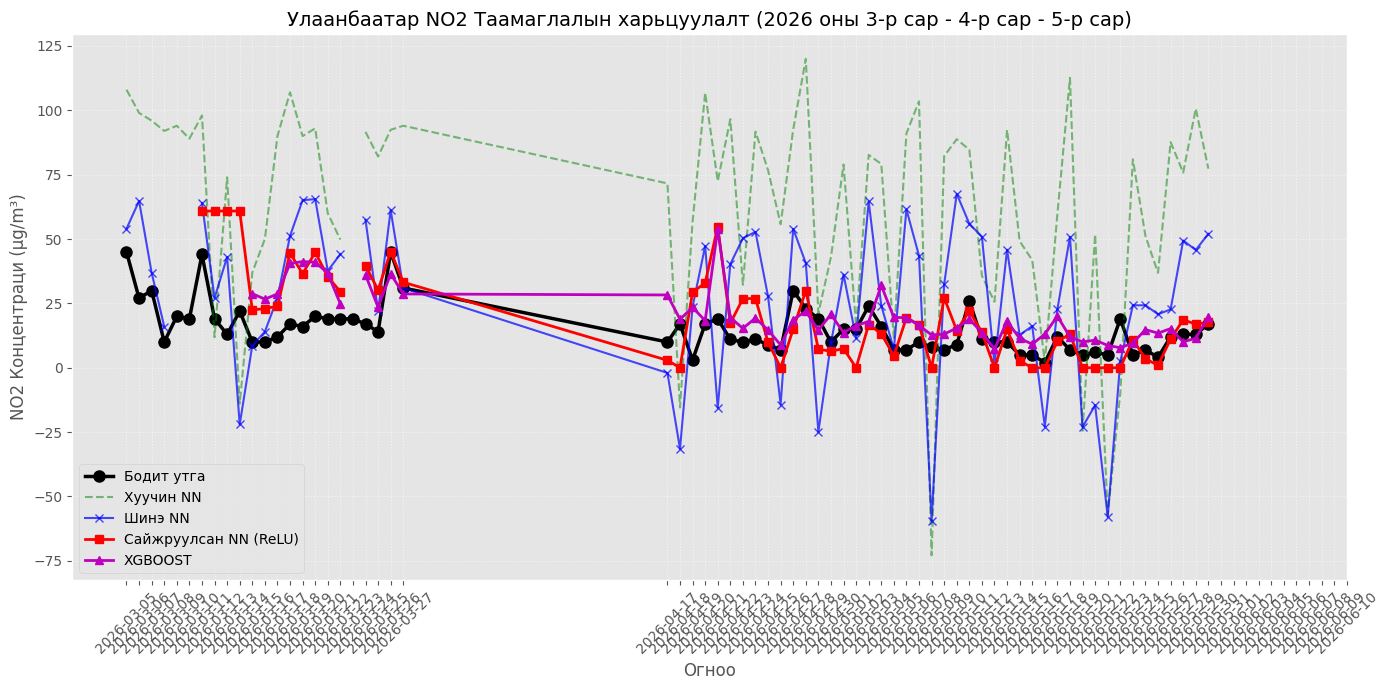

--- Сүүлийн өдрийн (2026-06-10) байдал ---
Бодит утга: nan


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r'C:\Users\Dell\Documents\Kaggle ML\Air quaility in Ub\content\Үр дүн.xlsx'

try:
    df_results = pd.read_excel(file_path).transpose()
    df_results.columns = df_results.iloc[0]
    df_results = df_results.drop(df_results.index[0])
    df_results.index = pd.to_datetime(df_results.index)

    for col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col], errors='coerce')

    plt.figure(figsize=(14, 7))
    plt.plot(df_results.index, df_results['Real NO2 '], 'ko-', label='Бодит утга', linewidth=2.5, markersize=8)
    plt.plot(df_results.index, df_results['NN'],             'g--', label='Хуучин NN', alpha=0.5)
    plt.plot(df_results.index, df_results['Шинэ NN'],        'b-x', label='Шинэ NN', alpha=0.7)
    plt.plot(df_results.index, df_results['Сайжруулсан NN'], 'r-s', label='Сайжруулсан NN (ReLU)', linewidth=2)
    plt.plot(df_results.index, df_results['XGBOOST'],        'm-^', label='XGBOOST', linewidth=2)

    plt.title('Улаанбаатар NO2 Таамаглалын харьцуулалт (2026 оны 3-р сар - 4-р сар - 5-р сар)', fontsize=14)
    plt.ylabel('NO2 Концентраци (µg/m³)')
    plt.xlabel('Огноо')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(df_results.index, rotation=45)
    plt.tight_layout()
    plt.show()

    last_row = df_results.iloc[-1]
    last_date = df_results.index[-1].strftime('%Y-%m-%d')
    print(f"--- Сүүлийн өдрийн ({last_date}) байдал ---")
    print(f"Бодит утга: {last_row['Real NO2 ']:.2f}")
    if 'Сайжруулсан NN' in last_row and not pd.isna(last_row['Сайжруулсан NN']):
        print(f"Сайжруулсан NN таамаглал: {last_row['Сайжруулсан NN']:.2f}")
        error = abs(last_row['Real NO2 '] - last_row['Сайжруулсан NN'])
        print(f"Зөрүү: {error:.2f} µg/m³")

except Exception as e:
    print(f"Алдаа гарлаа: {e}")

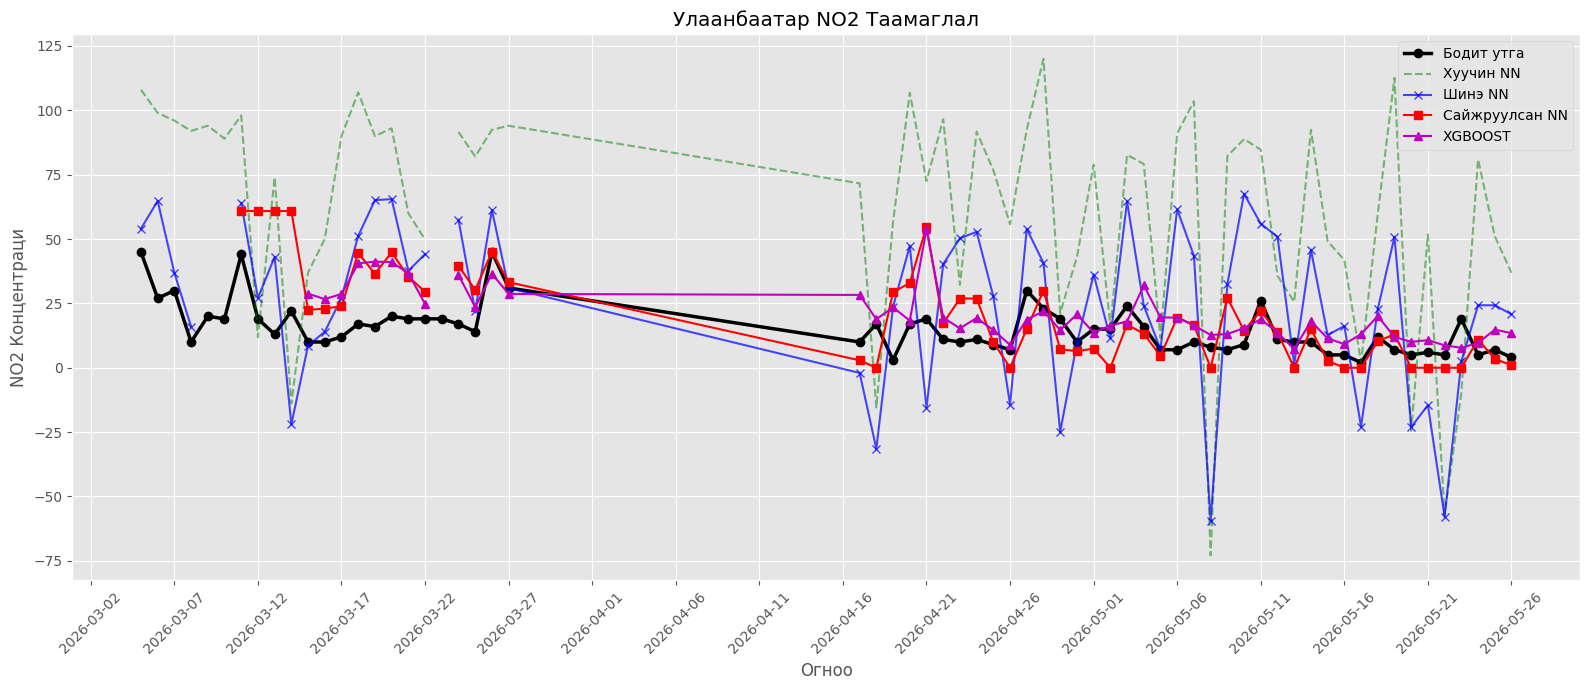

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = r'C:\Users\Dell\Documents\Kaggle ML\Air quaility in Ub\content\Үр дүн.xlsx'

df_results = pd.read_excel(file_path).transpose()

df_results.columns = df_results.iloc[0]
df_results = df_results.drop(df_results.index[0])

# datetime болгох
df_results.index = pd.to_datetime(df_results.index)

# numeric болгох
for col in df_results.columns:
    df_results[col] = pd.to_numeric(df_results[col], errors='coerce')

# хоосон мөр устгах
df_results = df_results.dropna(how='all')

#  2026-05-26 хүртэлх дата үлдээх
df_results = df_results[df_results.index <= '2026-05-30']

plt.figure(figsize=(16,7))

plt.plot(df_results.index, df_results['Real NO2 '],
         'ko-', label='Бодит утга', linewidth=2.5)

plt.plot(df_results.index, df_results['NN'],
         'g--', label='Хуучин NN', alpha=0.5)

plt.plot(df_results.index, df_results['Шинэ NN'],
         'b-x', label='Шинэ NN', alpha=0.7)

plt.plot(df_results.index, df_results['Сайжруулсан NN'],
         'r-s', label='Сайжруулсан NN')

plt.plot(df_results.index, df_results['XGBOOST'],
         'm-^', label='XGBOOST')

plt.title('Улаанбаатар NO2 Таамаглал')
plt.xlabel('Огноо')
plt.ylabel('NO2 Концентраци')

plt.legend()
plt.grid(True)

#  Он-Сар-Өдөр формат
ax = plt.gca()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

#  5 хоног тутам огноо
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

CO, NO, NO2, SO2 тархалтыг станц бүрээр харах

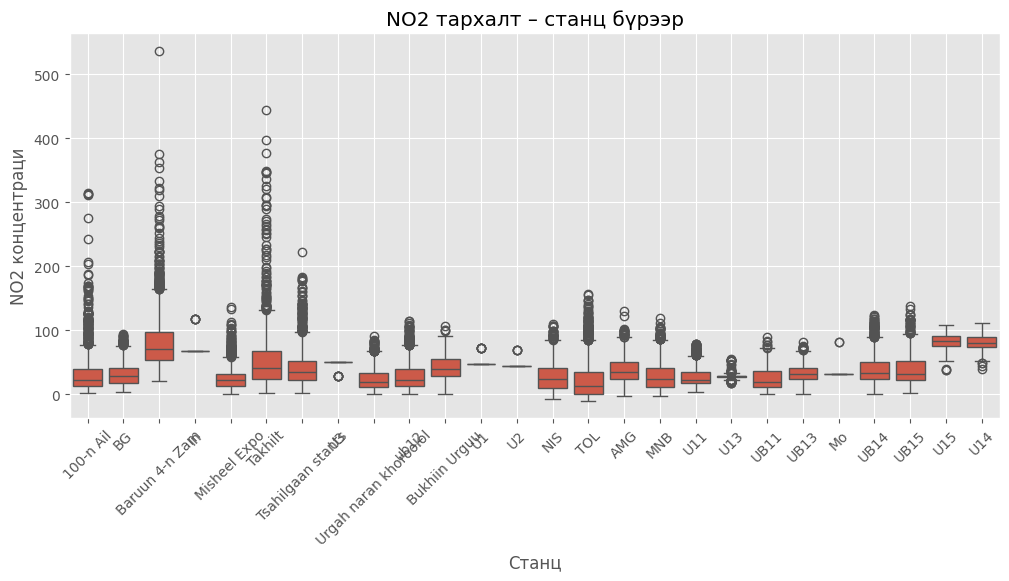

In [41]:
pollutants = ['NO2']

for p in pollutants:
    plt.figure(figsize=(12,5))
    sns.boxplot(
        data=df_final_long,
        x='Station',
        y=p
    )
    plt.xticks(rotation=45)
    plt.title(f'{p} тархалт – станц бүрээр')
    plt.ylabel(f'{p} концентраци')
    plt.xlabel('Станц')
    plt.grid(True)
    plt.show()

NO2 гэх мэт алдагдсан өгөгдлийн хувь (%)

date | T | WD | WS | CO | NO ... — өгөгдлийг харах

In [ ]:
df_final_long[['date', 'T', 'WD', 'WS', 'CO', 'NO', 'NO2', 'SO2']].head(10)


Нэг станцын цаг хугацааны өөрчлөлт (Line chart)

In [ ]:
station_name = '100-n Ail'

df_station = df_final_long[df_final_long['Station'] == station_name]

plt.figure(figsize=(12,5))

plt.plot(df_station['date'], df_station['NO2'], label='NO2')

plt.legend()
plt.title(f'{station_name} – бохирдлын хугацааны өөрчлөлт')
plt.xlabel('Огноо')
plt.ylabel('Концентраци')
plt.grid(True)
plt.show()


Цаг уур <--> бохирдлын хамаарал (Scatter)

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df_final_long['T'], df_final_long['NO2'], alpha=0.4)
plt.xlabel('Температур (°C)')
plt.ylabel('NO2')
plt.title('Температур ба NO2-ийн хамаарал')
plt.grid(True)
plt.show()


In [ ]:
forecast_period = pd.date_range(start='2026-02-11', periods=9, freq='D')   # 9 өдөр л

predicted_no2 = [129, 77, 93, 10, 41, 52, 39, 25, 43]

forecast_df_past = pd.DataFrame({
    'Date': forecast_period,
    'Station': '100-n Ail',
    'Predicted_NO2': predicted_no2
})

forecast_df_past.to_excel('NO2_forecast_Feb11_19_2026.xlsx', index=False)
print(forecast_df_past)

In [ ]:
# df_analysis нь 2020-2025 оны цэвэрлэсэн, цаг тутмын дата
# Жилээр дахин хэмжээсэлж (resample), дундаж утгыг тооцох
df_yearly_avg = df_analysis.resample('Y').mean()
df_yearly_avg.index = df_yearly_avg.index.year # Индексийг зөвхөн жилээр харуулах

# PM2.5 (P25) болон CO-г харуулахын тулд баганын нэрсийг сонгох
P25_CO_cols = [col for col in df_yearly_avg.columns if 'P25' in col or 'CO' in col]

print("### 1. Жил Тус Бүрийн Дундаж Үзүүлэлтүүд (6 AVG) ###")
print("-" * 60)

if not df_yearly_avg.empty and P25_CO_cols:
    # Зөвхөн P25 болон CO-г харуулах (Хүснэгт хэт томрохгүйн тулд)
    print(df_yearly_avg[P25_CO_cols].to_string(float_format="%.2f"))
    print("\n*Дээрх хүснэгтэд P25 ба CO-ийн жил тус бүрийн дундаж утгыг харуулав.")
else:
    print("Анхаар: Жилийн дундаж утгыг тооцох боломжгүй байна.")

In [ ]:
# 6 Жилийн Дунджуудын Нийт Дундаж

# df_yearly_avg дээр үндэслэн нийт дунджийг тооцох
df_overall_avg = df_yearly_avg.mean().to_frame().T
df_overall_avg.index = ['2020-2025 (Нийт Дундаж)']

print("\n### 2. 6 Жилийн Нийт Дундаж Үзүүлэлтүүд (1 AVG) ###")
print("-" * 60)

if not df_overall_avg.empty and P25_CO_cols:
    print(df_overall_avg[P25_CO_cols].to_string(float_format="%.2f"))
    print("\n*Энэ нь 2020-2025 оны ЖИЛ ТУС БҮРИЙН ДУНДАЖУУДЫН нийт дундаж утга юм.")
else:
    print("Анхаар: Нийт дундаж утгыг тооцох боломжгүй байна.")

In [ ]:
# --- 3. Жил Тус Бүрийн PM2.5-ийн Өөрчлөлтийг Графикаар Харуулах ---

p25_cols_yearly = [col for col in df_yearly_avg.columns if 'P25' in col]

if not df_yearly_avg.empty and p25_cols_yearly:
    plt.figure(figsize=(14, 7))
    
    # Жилийн дундаж PM2.5-ийг зурна
    df_yearly_avg[p25_cols_yearly].plot(kind='bar', ax=plt.gca())

    # 6 жилийн нийт дунджийг шугамаар нэмэх
    # Нийт дундаж утгыг df_overall_avg-с авна
    overall_p25_avg = df_overall_avg[p25_cols_yearly].mean(axis=1).iloc[0]
    plt.axhline(y=overall_p25_avg, color='gray', linestyle='--', linewidth=2, label=f'6 Жилийн Нийт Дундаж ({overall_p25_avg:.2f})')
    
    plt.title('Жил Тус Бүрийн PM2.5-ийн Дундаж Концентрацийн Өөрчлөлт (2020-2025)', fontsize=16)
    plt.ylabel('PM2.5 Дундаж (мкг/м3)', fontsize=12)
    plt.xlabel('Жил', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Станц', loc='upper right')
    plt.grid(axis='y', linestyle='--')
    plt.show()

In [ ]:
# --- 5. PM2.5-ийн Нийт Дунджийг Графикаар Харуулах ---

if 'df_p25_avg_sorted' in locals():
    plt.figure(figsize=(14, 7))
    
    # График зурахдаа эрэмбэлсэн PM2.5-ийн дунджийг ашиглана
    df_p25_avg_sorted['2020-2025 (Overall Avg)'].plot(kind='bar', color='darkred')

    # Нийт дунджийн хил хязгаарыг (WHO-ийн жилийн хэмжээ 5 мкг/м3) харуулах
    plt.axhline(y=5, color='green', linestyle='-', linewidth=2, label='WHO (Жилийн хэмжээ: 5 мкг/м3)')
    
    plt.title('2020-2025 оны PM2.5-ийн Нийт Дундаж (Станц Тус Бүрээр)', fontsize=16)
    plt.ylabel('PM2.5 Нийт Дундаж (мкг/м3)', fontsize=12)
    plt.xlabel('Хяналтын Станц', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

In [ ]:
# 5 Жил Тус Бүрийн Дундаж (2020-2025) ---

# df_analysis нь 2020-2025 оны цэвэрлэсэн, цаг тутмын дата
# Жилээр дахин хэмжээсэлж (resample), дундаж утгыг тооцох
df_yearly = df_analysis.resample('Y').mean()
df_yearly.index = df_yearly.index.year # Индексийг зөвхөн жилээр харуулах

print("### Жил Тус Бүрийн Дундаж Үзүүлэлтүүд (2020-2025) ###")
print("Жилийн дундаж утгууд нь PM2.5-ийн жилийн трендийг харахад чухал.")

# Зөвхөн PM2.5 (P25) болон CO-г харуулах
P25_CO_cols = [col for col in df_yearly.columns if 'P25' in col or 'CO' in col]

if not df_yearly.empty and P25_CO_cols:
    print(df_yearly[P25_CO_cols])
else:
    print("Анхаар: Жилийн дундаж утгыг тооцох боломжгүй байна (df_analysis хоосон).")

In [ ]:
#  Жил Тус Бүрийн PM2.5-ийн Өөрчлөлтийг Графикаар Харуулах 
df_overall_avg = df_analysis.mean().to_frame().T
df_overall_avg.index = ['2020-2025 (Overall Avg)']

p25_cols_yearly = [col for col in df_yearly.columns if 'P25' in col]

if not df_yearly.empty and p25_cols_yearly:
    plt.figure(figsize=(14, 7))
    
    # Жилийн дундаж PM2.5-ийг зурна
    df_yearly[p25_cols_yearly].plot(kind='bar', ax=plt.gca())

    # 5 жилийн нийт дунджийг шугамаар нэмэх
    overall_p25_avg = df_overall_avg[p25_cols_yearly].mean(axis=1).iloc[0]
    plt.axhline(y=overall_p25_avg, color='gray', linestyle='--', linewidth=2, label=f'5 Жилийн Нийт Дундаж ({overall_p25_avg:.2f})')

    plt.title('Жил Тус Бүрийн PM2.5-ийн Дундаж Концентрацийн Өөрчлөлт (2020-2025)', fontsize=16)
    plt.ylabel('PM2.5 Дундаж (мкг/м3)', fontsize=12)
    plt.xlabel('Жил', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Станц', loc='upper right')
    plt.grid(axis='y', linestyle='--')
    plt.show()

In [ ]:
#  5 Жилийн (2020-2025) Нийт Дундаж 

# df_analysis (2020-2025 оны бүх цаг тутмын дата) -ийн бүх мөрний дунджийг тооцох
df_overall_avg = df_analysis.mean().to_frame().T
df_overall_avg.index = ['2020-2025 (Overall Avg)']

print("\n### 5 Жилийн (2020-2054) Нийт Дундаж Үзүүлэлтүүд ###")
print("Энэ нь бүх жилийн өдөр тутмын дундаж утгуудыг нэгтгэсэн нийт дундаж юм.")

if not df_overall_avg.empty and P25_CO_cols:
    # Нийт дундаж утгуудыг харуулах
    print(df_overall_avg[P25_CO_cols])
else:
    print("Анхаар: Нийт дундаж утгыг тооцох боломжгүй байна.")

In [ ]:
#  PM2.5-ийн Сар/Улирлын Дундаж

# df_analysis-ийг ашиглан сарын дундаж утгыг тооцох
# (Энэ хэсгийг таны Notebook-д байсан тул засаж орууллаа. 'P25' гэж ашиглана.)
df_monthly = df_analysis.resample('M').mean()
df_monthly['Month'] = df_monthly.index.month

# P25-тэй холбоотой багануудыг сонгох
p25_monthly_cols = [col for col in df_monthly.columns if 'P25' in col]

if p25_monthly_cols:
    # 5 жилийн сарын дундаж утгыг тооцох (Сар тус бүрээр бүлэглэж дундажлах)
    df_pm_month_avg = df_monthly[p25_monthly_cols + ['Month']].groupby('Month').mean()

    plt.figure(figsize=(12, 6))
    df_pm_month_avg.plot(kind='bar', ax=plt.gca())

    plt.title('PM2.5-ийн Сар Тус Бүрийн Дундаж Концентраци (2020-2025)', fontsize=16)
    plt.ylabel('PM2.5 Дундаж (мкг/м3)', fontsize=12)
    plt.xlabel('Сар', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Станц', loc='upper left')
    plt.grid(axis='y')
    plt.show()

In [ ]:
# Жил Тус Бүрийн Дундаж Утгыг Тооцох (6 AVG)=
if not df_analysis.empty:
    
    # Жилээр дахин хэмжээсэлж (resample), дундаж утгыг тооцох
    df_yearly_avg = df_analysis.resample('Y').mean()
    df_yearly_avg.index = df_yearly_avg.index.year 

    # PM2.5 (P25) болон CO-г харуулахын тулд баганын нэрсийг сонгох
    P25_CO_cols = [col for col in df_yearly_avg.columns if 'P25' in col or 'CO' in col]

    print("\n### 1. Жил Тус Бүрийн Дундаж Үзүүлэлтүүд (6 AVG) ###")
    print("-" * 60)

    if P25_CO_cols:
        # Зөвхөн P25 болон CO-г харуулах
        print(df_yearly_avg[P25_CO_cols].to_string(float_format="%.2f"))
    
    # --- 5. 6 Жилийн Нийт Дундаж Утгыг Тооцох (1 AVG) ---
    # df_yearly_avg дээр үндэслэн нийт дунджийг тооцох
    df_overall_avg = df_yearly_avg.mean().to_frame().T
    df_overall_avg.index = ['2020-2025 (Нийт Дундаж)']

    print("\n### 2. 6 Жилийн Нийт Дундаж Үзүүлэлтүүд (1 AVG) ###")
    print("-" * 60)

    if P25_CO_cols:
        print(df_overall_avg[P25_CO_cols].to_string(float_format="%.2f"))

    # --- 6. PM2.5-ийн Жилийн Өөрчлөлтийг Графикаар Харуулах ---
    p25_cols_yearly = [col for col in df_yearly_avg.columns if 'P25' in col]

    if p25_cols_yearly:
        plt.figure(figsize=(14, 7))
        
        # Жилийн дундаж PM2.5-ийг зурна
        df_yearly_avg[p25_cols_yearly].plot(kind='bar', ax=plt.gca())

        # 6 жилийн нийт дунджийг шугамаар нэмэх
        overall_p25_avg = df_overall_avg[p25_cols_yearly].mean(axis=1).iloc[0]
        
        # WHO-ийн жилийн стандартыг нэмэх (5 мкг/м3)
        plt.axhline(y=5, color='green', linestyle='-', linewidth=2, label='WHO (Жилийн хэмжээ: 5 мкг/м3)')
        
        plt.axhline(y=overall_p25_avg, color='gray', linestyle='--', linewidth=2, label=f'6 Жилийн Нийт Дундаж ({overall_p25_avg:.2f})')
        
        plt.title('Жил Тус Бүрийн PM2.5-ийн Дундаж Концентрацийн Өөрчлөлт (2020-2025)', fontsize=16)
        plt.ylabel('PM2.5 Дундаж (мкг/м3)', fontsize=12)
        plt.xlabel('Жил', fontsize=12)
        plt.xticks(rotation=0)
        plt.legend(title='Станц', loc='upper right')
        plt.grid(axis='y', linestyle='--')
        plt.show('yearly_p25_average_comparison.png')
        plt.close()
        print("\nГрафик үүсгэсэн: yearly_p25_average_comparison.png")
    
else:
    print("df_analysis DataFrame хоосон тул шинжилгээ хийх боломжгүй байна. Файл унших алдаагаа шалгана уу.")

In [ ]:


# df_analysis-ийг ашиглан 2024 оны 12-р сарын мэдээллийг шүүж авах
try:
    df_dec_2024 = df_analysis.loc['2024-12']
except KeyError:
    print("Алдаа: df_analysis DataFrame-д 2024 оны 12-р сарын мэдээлэл олдсонгүй.")
    df_dec_2024 = pd.DataFrame() 

# P25-тэй холбоотой багануудыг сонгох
p25_daily_cols = [col for col in df_dec_2024.columns if 'P25' in col]

if not df_dec_2024.empty and p25_daily_cols:
    
    df_dec_2024_pm = df_dec_2024[p25_daily_cols].copy()
    
    if not df_dec_2024_pm.empty:
        
        # 🛑 ЗАСВАР: Бүх станцуудын өдөр тутмын дунджийг тооцох (axis=1)
        df_mean_p25 = df_dec_2024_pm.mean(axis=1)
        
        plt.figure(figsize=(15, 6))
        ax = plt.gca()
        
        # Ганц дундаж утгыг шугаман графикаар зурах
        df_mean_p25.plot(ax=ax, linewidth=3, color='firebrick', label='Бүх Станцын Дундаж')

        # 🛑 Y ТЭНХЛЭГИЙГ ХЯЗГААРЛАХ 🛑
        # PM2.5-ийн дээд хязгаарыг 500 мкг/м3 гэж тогтооё.
        ax.set_ylim(0, 500)
        
        plt.title('PM2.5-ийн Өдөр Тутмын Дундаж Концентрацийн Хэлбэлзэл (2024 Оны 12-р Сар)', fontsize=16)
        plt.ylabel('PM2.5 Дундаж Концентраци (мкг/м3)', fontsize=12)
        plt.xlabel('Огноо (12-р сар)', fontsize=12)
        
        # Ганц шугам байгаа тул домог шаардлагагүй, гэхдээ label-ийг харуулъя
        plt.legend(loc='upper right')
        
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Анхааруулга: 2024 оны 12-р сарын PM2.5-ийн мэдээлэл олдсонгүй.")
else:
    print("Мэдээлэл шүүх боломжгүй: 2024 оны 12-р сарын мэдээлэл эсвэл PM2.5-ийн багана олдсонгүй.")

In [ ]:

# df_analysis-ийг ашиглан 2024 оны 12-р сарын 9-ний өдрийн мэдээллийг шүүж авах
date_to_filter = '2024-12-09'

try:
    # Огнооны индексээр зөвхөн тухайн өдрийг шүүж байна
    df_hourly = df_analysis.loc[date_to_filter]
except KeyError:
    print(f"Алдаа: df_analysis DataFrame-д {date_to_filter} огнооны мэдээлэл олдсонгүй эсвэл индекс буруу байна.")
    df_hourly = pd.DataFrame() 

# P25-тэй холбоотой багануудыг сонгох
p25_hourly_cols = [col for col in df_hourly.columns if 'P25' in col]

if not df_hourly.empty and p25_hourly_cols:
    
    # Зөвхөн PM2.5-ийн багануудыг агуулсан DataFrame-ийг бэлдэх
    df_hourly_pm = df_hourly[p25_hourly_cols].copy()
    
    if not df_hourly_pm.empty:
        plt.figure(figsize=(15, 6))
        
        # Цаг тутам мэдээллийг шугаман графикаар зурах
        ax = plt.gca()
        df_hourly_pm.plot(ax=ax, linewidth=2, marker='o', markersize=4) # Цаг тутамд маркер нэмэв

        plt.title(f'PM2.5-ийн Цаг Тутам Концентрацийн Хэлбэлзэл ({date_to_filter})', fontsize=16)
        plt.ylabel('PM2.5 Концентраци (мкг/м3)', fontsize=12)
        plt.xlabel('Цаг', fontsize=12)
        
        # X тэнхлэг дээр цагийг тодорхой харуулах
        ax.set_xticks(df_hourly_pm.index)
        ax.set_xticklabels([f'{t.hour:02d}:00' for t in df_hourly_pm.index], rotation=45, ha='right')
        
        # Домогийг харуулах (Станцын нэрийг харуулах)
        ax.legend(title='Станц', loc='upper left') 
        
        # Y тэнхлэгийн хязгаарыг бодит байдалд тохируулах (жишээ нь, 0-1000)
        # Хэрэв хэт гажиг утга байвал илүү хязгаарлах хэрэгтэй
        ax.set_ylim(0, df_hourly_pm.max().max() * 1.1 if df_hourly_pm.max().max() < 1000 else 1000)
        
        plt.grid(axis='both', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Анхааруулга: {date_to_filter} огнооны PM2.5-ийн мэдээлэл олдсонгүй.")
else:
    print(f"Мэдээлэл шүүх боломжгүй: {date_to_filter} огнооны мэдээлэл эсвэл PM2.5-ийн багана олдсонгүй.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# df_analysis-ийг ашиглан 2024 оны мэдээллийг шүүж авах
try:
    df_2024 = df_analysis.loc['2024']
except KeyError:
    print("Алдаа: df_analysis DataFrame-д 2024 оны мэдээлэл олдсонгүй.")
    df_2024 = pd.DataFrame() 

# P25-тэй холбоотой багануудыг сонгох
p25_daily_cols = [col for col in df_2024.columns if 'P25' in col]

if not df_2024.empty and p25_daily_cols:
    
    df_2024_pm = df_2024[p25_daily_cols].copy()
    
    # Өвөл, Зуны мэдээллийг шүүх
    winter_months_filter = df_2024_pm.index.month.isin([1, 12])
    df_winter = df_2024_pm[winter_months_filter]
    
    summer_months_filter = df_2024_pm.index.month.isin([6, 7])
    df_summer = df_2024_pm[summer_months_filter]

    # Станц тус бүрийн Өвөл, Зуны ДУНДАЖ-ийг тооцох
    winter_avg = df_winter.mean().rename('Winter (Jan, Dec)')
    summer_avg = df_summer.mean().rename('Summer (Jun, Jul)')
    
    # Үр дүнгийн DataFrame-ийг нэгтгэх
    df_comparison = pd.concat([winter_avg, summer_avg], axis=1)
    
    # DataFrame-ийг дүрслэлд зориулж "урт" форматад оруулах (melt)
    df_comparison['Station'] = [col.split('_')[-1] for col in df_comparison.index]
    df_long = df_comparison.melt(id_vars='Station', 
                                 var_name='Season', 
                                 value_name='PM2.5 Average ($\mu g/m^3$)')

    # Дүрслэх
    plt.figure(figsize=(12, 7))
    
    # Bar plot ашиглан улирлын дунджийг харьцуулах
    sns.barplot(x='Station', y='PM2.5 Average ($\mu g/m^3$)', hue='Season', data=df_long, 
                palette={'Winter (Jan, Dec)': 'firebrick', 'Summer (Jun, Jul)': 'skyblue'})
    
    plt.title('PM2.5-ийн Станц Тус Бүрийн Өвөл/Зуны Дундаж Концентрацийн Харьцуулалт (2024 Он)', fontsize=14)
    plt.xlabel('Хяналтын Станц', fontsize=12)
    plt.ylabel('PM2.5 Дундаж ($\mu g/m^3$)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Улирал')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("Мэдээлэл шүүх боломжгүй: 2024 оны мэдээлэл эсвэл PM2.5-ийн багана олдсонгүй.")

In [ ]:


# df_analysis-ийг ашиглан 2024 оны мэдээллийг шүүж авах
try:
    df_2024 = df_analysis.loc['2024']
except KeyError:
    print("Алдаа: df_analysis DataFrame-д 2024 оны мэдээлэл олдсонгүй.")
    df_2024 = pd.DataFrame() 

# 🛑 ЗАСВАР 1: NO-тэй холбоотой багануудыг сонгох
NO_daily_cols = [col for col in df_2024.columns if 'NO' in col and 'NO2' not in col and 'NOx' not in col]
# 'NO' гэсэн нэртэй багануудыг (NO2, NOx-ийг оруулахгүйгээр) сонгоно.

if not df_2024.empty and NO_daily_cols:
    
    # 🛑 ЗАСВАР 2: NO-ийн багануудыг агуулсан DataFrame-ийг бэлдэх
    df_2024_NO = df_2024[NO_daily_cols].copy()
    
    # Өвөл, Зуны мэдээллийг шүүх
    winter_months_filter = df_2024_NO.index.month.isin([1, 12])
    df_winter = df_2024_NO[winter_months_filter]
    
    summer_months_filter = df_2024_NO.index.month.isin([6, 7])
    df_summer = df_2024_NO[summer_months_filter]

    # Станц тус бүрийн Өвөл, Зуны ДУНДАЖ-ийг тооцох
    winter_avg = df_winter.mean().rename('Winter (Jan, Dec)')
    summer_avg = df_summer.mean().rename('Summer (Jun, Jul)')
    
    # Үр дүнгийн DataFrame-ийг нэгтгэх
    df_comparison = pd.concat([winter_avg, summer_avg], axis=1)
    
    # DataFrame-ийг дүрслэлд зориулж "урт" форматад оруулах (melt)
    # Станцын нэрийг гаргаж авах
    df_comparison['Station'] = [col.split('_')[-1] for col in df_comparison.index]
    df_long = df_comparison.melt(id_vars='Station', 
                                 var_name='Season', 
                                 # 🛑 ЗАСВАР 3: value_name-ийг NO-д зориулж өөрчлөх
                                 value_name='NO Average ($\mu g/m^3$)')

    # Дүрслэх
    plt.figure(figsize=(12, 7))
    
    # Bar plot ашиглан улирлын дунджийг харьцуулах
    sns.barplot(x='Station', y='NO Average ($\mu g/m^3$)', hue='Season', data=df_long, 
                palette={'Winter (Jan, Dec)': 'firebrick', 'Summer (Jun, Jul)': 'skyblue'})
    
    plt.title('NO-ийн Станц Тус Бүрийн Өвөл/Зуны Дундаж Концентрацийн Харьцуулалт (2024 Он)', fontsize=14)
    plt.xlabel('Хяналтын Станц', fontsize=12)
    plt.ylabel('NO Дундаж ($\mu g/m^3$)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Улирал')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("Мэдээлэл шүүх боломжгүй: 2024 оны NO-ийн мэдээлэл олдсонгүй.")

In [ ]:

# df_analysis-ийг ашиглан 2024 оны мэдээллийг шүүж авах
try:
    df_2024 = df_analysis.loc['2024']
except KeyError:
    print("Алдаа: df_analysis DataFrame-д 2024 оны мэдээлэл олдсонгүй.")
    df_2024 = pd.DataFrame() 

# NO-тэй холбоотой багануудыг сонгох
NO_daily_cols = [col for col in df_2024.columns if 'NO' in col and 'NO2' not in col and 'NOx' not in col]

if not df_2024.empty and NO_daily_cols:
    
    df_2024_NO = df_2024[NO_daily_cols].copy()
    
    # 1. Наадмын өдрүүдийг сонгох (7-р сарын 11, 12, 13, 14)
    naadam_dates = pd.to_datetime(['2024-07-11', '2024-07-12', '2024-07-13', '2024-07-14'])
    df_naadam = df_2024_NO.loc[df_2024_NO.index.isin(naadam_dates)]
    
    # 2. Наадмын өмнөх ажлын өдрүүдийг сонгох (7-р сарын 8, 9, 10)
    workday_dates = pd.to_datetime(['2024-07-08', '2024-07-09', '2024-07-10'])
    df_workdays = df_2024_NO.loc[df_2024_NO.index.isin(workday_dates)]

    # 3. Станц тус бүрийн дундаж утгыг тооцох
    naadam_avg = df_naadam.mean().rename('Баярын өдрүүд (Наадам)')
    workday_avg = df_workdays.mean().rename('Ажлын өдрүүд (Өмнөх)')
    
    # 4. Үр дүнгийн DataFrame-ийг нэгтгэх
    df_comparison = pd.concat([workday_avg, naadam_avg], axis=1)
    
    # DataFrame-ийг дүрслэлд зориулж "урт" форматад оруулах (melt)
    df_comparison['Station'] = [col.split('_')[-1] for col in df_comparison.index]
    df_long = df_comparison.melt(id_vars='Station', 
                                 var_name='Period', 
                                 value_name='NO Average ($\mu g/m^3$)')

    # 5. Дүрслэх
    plt.figure(figsize=(12, 7))
    
    sns.barplot(x='Station', y='NO Average ($\mu g/m^3$)', hue='Period', data=df_long, 
                palette={'Ажлын өдрүүд (Өмнөх)': 'gray', 'Баярын өдрүүд (Наадам)': 'forestgreen'})
    
    plt.title('NO-ийн Дундаж Концентрацийн Харьцуулалт (Наадам vs Ажлын Өдөр, 2024 Он)', fontsize=14)
    plt.xlabel('Хяналтын Станц', fontsize=12)
    plt.ylabel('NO Дундаж ($\mu g/m^3$)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Хугацаа')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("Мэдээлэл шүүх боломжгүй: 2024 оны NO-ийн мэдээлэл олдсонгүй.")

In [ ]:

from matplotlib.dates import DateFormatter

# df_analysis-ийг ашиглан 2024 оны мэдээллийг шүүж авах
try:
    df_2024 = df_analysis.loc['2024']
except KeyError:
    print("Алдаа: df_analysis DataFrame-д 2024 оны мэдээлэл олдсонгүй.")
    df_2024 = pd.DataFrame() 

# NO-тэй холбоотой багануудыг сонгох
NO_daily_cols = [col for col in df_2024.columns if 'NO' in col and 'NO2' not in col and 'NOx' not in col]

if not df_2024.empty and NO_daily_cols:
    
    df_2024_NO = df_2024[NO_daily_cols].copy()
    
    # 1. Шинжилгээ хийх хугацааг сонгох (7-р сарын 1-нээс 30-нийг хүртэл)
    start_date = '2024-07-01'
    end_date = '2024-07-28'
    df_naadam_week = df_2024_NO.loc[start_date:end_date]
    
    if not df_naadam_week.empty:
        
        # ЗАСВАР!: Бүх станцын дундаж утгыг (мөрийн дагуу) тооцох
        # axis=1 нь мөрүүдийн дунджийг (өөрөөр хэлбэл, тухайн өдрийн станцуудын дунджийг) тоолно.
        df_mean_no = df_naadam_week.mean(axis=1)
        
        plt.figure(figsize=(14, 7))
        ax = plt.gca()
        
        # 2. Зөвхөн дундаж утгыг ганц шугамаар дүрслэх
        df_mean_no.plot(ax=ax, linewidth=3, color='darkblue', label='Бүх Станцын Дундаж')

        # 3. Баярын өдрүүдийн хязгаарыг тэмдэглэх (7-р сарын 11-нээс эхлэн)
        naadam_start = pd.to_datetime('2024-07-11')
        ax.axvline(naadam_start, color='red', linestyle='--', label='Наадмын Эхлэл (7/11)')
        
        plt.title('NO Концентрацийн Өдөр Тутмын Хэлбэлзэл (Бүх Станцын Дундаж, 7-р Сарын Турш, 2024 Он)', fontsize=16)
        plt.ylabel('NO Дундаж Концентраци (мкг/м3)', fontsize=12)
        plt.xlabel('Огноо', fontsize=12)
        
        # X тэнхлэгийн форматыг өөрчлөх
        ax.xaxis.set_major_formatter(DateFormatter("%m/%d"))
        
        # 4. Домогийг харуулах (Дундаж шугам ба axvline-ийн домог)
        plt.legend(title='Хэмжээс / Үйл Явдал', loc='upper right')
        
        # Y тэнхлэгийн хязгаарыг гажиг утгагүйгээр тохируулах (жишээ нь, 500-аар хязгаарлах)
        max_val = df_mean_no.max()
        ax.set_ylim(0, max_val * 1.1 if max_val < 500 else 500)
        
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Анхааруулга: 7-р сарын 1-нээс 30-ны хоорондох NO-ийн мэдээлэл олдсонгүй.")
else:
    print("Мэдээлэл шүүх боломжгүй: 2024 оны NO-ийн багана олдсонгүй.")

In [ ]:
# --- . Бохирдуулагчдын Хамаарал (Correlation Heatmap) ---

# Зөвхөн Sharkhad станцын бохирдуулагчдыг сонгох
mo_cols = [col for col in df_daily.columns if 'UB14' in col]
# "Met_" гэсэн угтвар үгтэй бүх баганыг нэмэх жишээ
weather_cols = [col for col in df_daily.columns if 'Met_' in col]
mo_cols.extend(weather_cols)
# ... [өмнөх код] ...

# Зөвхөн Sharkhad станцын бохирдуулагчдыг сонгох
mo_cols = [col for col in df_daily.columns if 'UB14' in col]
# "Met_" гэсэн угтвар үгтэй бүх баганыг нэмэх жишээ
weather_cols = [col for col in df_daily.columns if 'Met_' in col]
mo_cols.extend(weather_cols)

# 🛑 АЛДААГ БАРИХ ШАЛГАЛТ 🛑
if not mo_cols:
    print("Анхааруулга: 'Sharkhad' эсвэл 'Met_' гэсэн утга агуулсан нэг ч багана олдсонгүй. Хамаарлын матриц үүсгэх боломжгүй.")
    # Олдсон багануудыг харуулах (хэрэв та мэдэхгүй бол)
    # print("Бодит баганууд:", df_daily.columns.tolist()) 
else:
    # Зөвхөн баганууд байвал corr() болон heatmap-ийг дуудна.
    df_corr = df_daily[mo_cols].corr()

    plt.figure(figsize=(10, 8))
    # ... [heatmap код] ...
    if len(df_corr.columns) > 10:
        sns.heatmap(df_corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='lightgray')
    else:
        sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='lightgray')

    plt.title('Sharkhad Станцын Үзүүлэлтүүдийн Хамаарлын Матриц', fontsize=16)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
df_corr = df_daily[mo_cols].corr()

plt.figure(figsize=(10, 8))
if len(df_corr.columns) > 10:
    sns.heatmap(df_corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='lightgray')
else:
    sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='lightgray')

plt.title('Sharkhad Станцын Үзүүлэлтүүдийн Хамаарлын Матриц', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# df_daily-ийн бүх баганын нэрсийг хэвлэх
print("df_daily-ийн баганууд:")
print(df_daily.columns.tolist())

In [ ]:
# 1. PM2.5-ийн Нийт Жилийн Дундаж Тренд (Бүх Станцын дундаж) 

# df_analysis-ийг ашиглан PM2.5-ийн бүх станцын дундаж (P25_City_Avg) -ийг тооцох
p25_only_cols = [col for col in df_analysis.columns if 'P25' in col]

if not p25_only_cols:
    print("PM2.5-ийн мэдээлэл олдсонгүй.")
else:
    # 1. Өдөр тутмын хотын дундаж PM2.5-ийг тооцох
    df_daily['P25_City_Avg'] = df_daily[p25_only_cols].mean(axis=1)

    # 2. Жил тутмын дундаж PM2.5-ийг тооцох
    df_yearly_city_avg = df_daily['P25_City_Avg'].resample('Y').mean()
    df_yearly_city_avg.index = df_yearly_city_avg.index.year

    plt.figure(figsize=(10, 6))
    
    # Bar Chart (Баганан график) нь жилийн харьцуулалтад илүү ойлгомжтой
    df_yearly_city_avg.plot(kind='bar', color='skyblue', edgecolor='black', linewidth=1)

    # 3.  жилийн стандартыг нэмэх
    plt.axhline(y=5, color='darkgreen', linestyle='--', linewidth=2, label='(Жилийн хэмжээ: 5 μg/m³)')
    
    plt.title('Улаанбаатар хотын PM2.5-ийн Жилийн Дундаж Түвшин (2020-2025)', fontsize=16)
    plt.ylabel('PM2.5 Концентраци (мкг/м³)', fontsize=14)
    plt.xlabel('Жил', fontsize=14)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

In [ ]:
#  Станц Тус Бүрийн PM2.5-ийн Нийт Дундаж ба Хэлбэлзэл 

# df_overall_avg-г тооцох (Бүх хугацааны нийт дундаж)
df_overall_avg_raw = df_analysis[p25_only_cols].mean().to_frame(name='Overall_Avg')

# Баганын нэрийг цэвэрлэх
df_overall_avg_raw.index = df_overall_avg_raw.index.str.replace('P25_', '')

df_overall_avg_sorted = df_overall_avg_raw.sort_values(by='Overall_Avg', ascending=False)


plt.figure(figsize=(14, 7))
# Bar Chart нь станцуудыг хамгийн ихээс бага руу эрэмбэлж харуулахад тохиромжтой
sns.barplot(
    x=df_overall_avg_sorted.index, 
    y='Overall_Avg', 
    data=df_overall_avg_sorted.reset_index(), 
    palette='Reds_d' # Хүчтэй улаанаас сул улаан руу шилжих
)

# 4. Жилийн стандартыг нэмэх
plt.axhline(y=5, color='darkgreen', linestyle='--', linewidth=2, label='Жилийн Хэмжээ')

plt.title('PM2.5-ийн Нийт Дундаж (2020-2025) - Бохирдлын Эрэмбэ', fontsize=16)
plt.ylabel('PM2.5 Нийт Дундаж (мкг/м³)', fontsize=14)
plt.xlabel('Хяналтын Станц', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# CO-ийн Нийт Дундаж Концентрацийн Эрэмбэ (Bar Chart)

co_cols = [col for col in df_daily.columns if 'CO_' in col]

if not co_cols:
    print("CO-ийн мэдээлэл хангалтгүй байна.")
else:
    # 1. CO-ийн нийт дундаж утгыг тооцох (Бүх хугацааны)
    # df_analysis-ийг ашиглаж, бүх хугацааны дундажийг тооцно
    df_co_avg_raw = df_analysis[co_cols].mean().to_frame(name='Overall_Avg')

    # Баганын нэрийг цэвэрлэх (Жишээ нь: CO_Takhilt -> Takhilt)
    df_co_avg_raw.index = df_co_avg_raw.index.str.replace('CO_', '')

    # Дунджаар эрэмбэлэх (Хамгийн ихээс бага руу)
    df_co_avg_sorted = df_co_avg_raw.sort_values(by='Overall_Avg', ascending=False)

    print("CO-ийн Нийт Дундаж (2020-2025) Эрэмбэлсэн Хүснэгт:")
    print(df_co_avg_sorted.to_string(float_format="%.2f"))

    plt.figure(figsize=(14, 7))
    
    # Bar Chart (Баганан график)
    sns.barplot(
        x=df_co_avg_sorted.index, 
        y='Overall_Avg', 
        data=df_co_avg_sorted.reset_index(), 
        palette='Blues_d' 
    )

    plt.title('CO-ийн Нийт Дундаж Концентраци (2020-2025) - Бохирдлын Эрэмбэ', fontsize=16)
    plt.ylabel('CO Нийт Дундаж (mg/m³)', fontsize=14)
    plt.xlabel('Хяналтын Станц', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()



In [ ]:
#  CO-ийн 30 Өдрийн Гүйдэг Дундаж Тренд (Тодотголтой) ---

co_cols = [col for col in df_daily.columns if 'CO_' in col]

# CO-ийн нийт дунджаар хамгийн өндөр үзүүлэлттэй 'CO_MNB' станцыг сонгов
HIGHLIGHT_CO_COL = 'CO_MNB' 

if not co_cols:
    print("CO-ийн мэдээлэл хангалтгүй байна.")
elif HIGHLIGHT_CO_COL not in co_cols:
    print(f"Анхаар: Тодотгохыг хүссэн '{HIGHLIGHT_CO_COL}' багана олдсонгүй. Боломжит CO-ийн баганууд: {co_cols[:3]}...")
else:
    # 30 өдрийн гүйдэг дундаж тооцох
    df_co_rolling = df_daily[co_cols].rolling(window=30, min_periods=1).mean()
    
    df_co_long = df_co_rolling.melt(ignore_index=False, var_name='Station', value_name='Concentration (mg/m³)')
    df_co_long = df_co_long.reset_index()

    plt.figure(figsize=(18, 7))
    
    # 1. Бусад бүх шугамыг бүдэг саарал өнгөөр зурах
    sns.lineplot(
        data=df_co_long[df_co_long['Station'] != HIGHLIGHT_CO_COL],
        x='date',
        y='Concentration (mg/m³)',
        hue='Station',
        palette=['gray'] * len(co_cols), 
        alpha=0.3,
        errorbar=None,
        legend=False 
    )
    
    # 2. MNB станцыг тод цэнхэр өнгөөр (Тодотгол)
    sns.lineplot(
        data=df_co_long[df_co_long['Station'] == HIGHLIGHT_CO_COL],
        x='date',
        y='Concentration (mg/m³)',
        color='blue', 
        linewidth=3,
        label=HIGHLIGHT_CO_COL,
        errorbar=None
    )
    
    # 3. MNS 4585:2020-ийн 8 цагийн дундаж хүлцэх хэмжээг нэмэх (Жишээ нь 5 mg/m3)
    plt.axhline(y=5, color='darkred', linestyle='--', alpha=0.7, label='MNS Хүлцэх Хэмжээ (Жишээ: 5 mg/m³)') 
    
    plt.title(f'CO Концентрацийн 30 Өдрийн Гүйдэг Дундаж Тренд (2020-2025) - {HIGHLIGHT_CO_COL}-ийг Тодотгов', fontsize=18)
    plt.xlabel('Огноо', fontsize=14)
    plt.ylabel('CO Концентраци (mg/m³)', fontsize=14)
    plt.legend(title='Тодотгосон Станц', loc='upper right')
    plt.grid(True, linestyle='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Шинжилгээ хийх бохирдуулагчид
analyzed_pollutants = ['CO', 'NO2', 'SO2']
pm_cols_for_stats = [col for col in df_analysis.columns if 'PM25' in col or 'P10' in col]

# Станцын нэрсийг гаргах (Жишээ: CO_Misheel Expo -> Misheel Expo)
def get_station_name(col):
    return col.split('_', 1)[1]

# Үр дүнгийн DataFrame-ийг үүсгэх
stats_list = []

# Станц тус бүрээр статистик тооцох
for station_abbr, station_name in STATION_MAP.items():

    # Станцын багануудыг сонгох
    station_cols = [col for col in df_analysis.columns if station_name in col]

    # Шинжилгээний үзүүлэлтүүдийг сонгох
    for pol in analyzed_pollutants:
        pol_col = [col for col in station_cols if col.startswith(f'{pol}_')]
        if pol_col:
            data = df_analysis[pol_col[0]].dropna()
            if not data.empty:
                stats = data.agg(['max', 'min', 'mean', 'std']).rename(pol_col[0])
                stats = stats.to_frame().T
                stats['Station'] = station_name
                stats['Pollutant'] = pol
                stats_list.append(stats)

    # PM2.5/P10-ийг тусад нь тооцох
    for pm_col in pm_cols_for_stats:
        if station_name in pm_col:
            data = df_analysis[pm_col].dropna()
            if not data.empty:
                stats = data.agg(['max', 'min', 'mean', 'std']).rename(pm_col)
                stats = stats.to_frame().T
                stats['Station'] = station_name
                stats['Pollutant'] = 'PM' # PM25 эсвэл P10-ийг "PM" гэж нэгтгэв
                stats_list.append(stats)

if stats_list:
    df_stats = pd.concat(stats_list)
    df_stats = df_stats[['Station', 'Pollutant', 'max', 'min', 'mean', 'std']]
    print("\n--- Станц Тус Бүрийн Үндсэн Статистик Үзүүлэлт (2020-2025) ---")
    print(df_stats.round(2))
else:
    print("\nСтатистик тооцох боломжтой мэдээлэл олдсонгүй.")

In [ ]:

#  Бохирдуулагч тус бүрээр дундаж утгыг харуулах (Бар График)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_stats,
    x='Pollutant', 
    y='mean', 
    hue='Station',
    palette='Spectral'
)
plt.title('Бохирдуулагч Тус Бүрийн Дундаж Концентрацийн Харьцуулалт (Станцуудаар)', fontsize=15)
plt.ylabel('Дундаж Концентраци')
plt.xlabel('Бохирдуулагч')
plt.xticks(rotation=0)
plt.legend(title='Станц', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#  Шинжилгээнд Шаардлагатай DataFrame

# Зөвхөн Бохирдуулагч/Үзүүлэлтийн багануудыг сонгох
pollutant_cols = [col for col in df_daily.columns if any(pol in col for pol in POLLUTANTS_TO_KEEP)]

# Өдөр тутмын дундаж датаг (df_daily) урт форматанд (Melt) шилжүүлэх
df_long = df_daily[pollutant_cols].melt(ignore_index=False, var_name='Station_Pollutant', value_name='Concentration')
df_long = df_long.reset_index()

# Баганыг задлах
df_long[['Pollutant', 'Station']] = df_long['Station_Pollutant'].str.split('_', expand=True, n=1)

# Баганын нэрийг стандартчилах (MNB/TOL/U11 гэх мэт товчлолууд үлдэж болно)
df_long['Station'] = df_long['Station'].replace(STATION_MAP)
df_long['Station'] = df_long['Station'].fillna(df_long['Station_Pollutant'].apply(lambda x: x.split('_')[-1]))

# Бохирдуулагч тус бүрээр станцуудын дундаж утгыг тооцох
df_stats = df_long.groupby(['Pollutant', 'Station'])['Concentration'].mean().reset_index(name='mean')
print(df_stats.head())

In [ ]:
# Гол Бохирдуулагчдыг Сонгож, Bar Plot

# Зөвхөн гол бохирдуулагчдыг сонгох
key_pollutants = ['P25', 'P10', 'CO','NO']
df_key_stats = df_stats[df_stats['Pollutant'].isin(key_pollutants)].copy()

# P25-ийн дундаж утгаар станцуудыг эрэмбэлэх
p25_order = df_key_stats[df_key_stats['Pollutant'] == 'P25'].sort_values(by='mean', ascending=False)['Station'].tolist()

plt.figure(figsize=(18, 8))
sns.barplot(
    data=df_key_stats,
    x='Station',  # Станц
    y='mean',     # Дундаж концентраци
    hue='Pollutant', # Бохирдуулагч
    hue_order=['P25', 'P10', 'CO','NO'], # Бохирдуулагчийн эрэмбэ
    order=p25_order, # P25-ийн түвшнээр станцуудыг эрэмбэлэх
    palette='viridis' # Илүү тод өнгө
)

plt.title('Гол Бохирдуулагчдын Дундаж Концентрацийн Харьцуулалт (2020-2025)', fontsize=18)
plt.ylabel('Дундаж Концентраци', fontsize=14)
plt.xlabel('Хяналтын Станц (PM2.5-аар Эрэмбэлсэн)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Бохирдуулагч', loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#  Дундаж ба Стандарт Хазайлтыг харуулах (Dot Plot with Error Bars)
# Стандарт хазайлт (std) нь алдааны шугам болно.

plt.figure(figsize=(14, 8))

# Бохирдуулагч тус бүрийн хувьд давталт хийх# --- 1. df_stats-г шаардлагатай статистик үзүүлэлтүүдээр (mean, std, max, min) дахин тооцох ---

# df_long-г ашиглан нэгтгэсэн, задлагдсан өгөгдөл
if 'df_long' not in locals():
    print("df_long DataFrame олдсонгүй. Өмнөх алхмыг ажиллуулах шаардлагатай.")
else:
    # df_stats-г дахин тооцох: mean, std, max, min
    df_stats = df_long.groupby(['Pollutant', 'Station'])['Concentration'].agg(['mean', 'std', 'max', 'min']).reset_index()

    print("--- Шинэчилсэн df_stats-ийн Эхний 5 Мөр ---")
    print(df_stats.head())

    # --- 2. Дундаж ба Стандарт Хазайлтыг харуулах (Dot Plot with Error Bars) ---
    # std-ийг алдааны шугам болгоно.

    key_pollutants = df_stats['Pollutant'].unique()
    num_plots = len(key_pollutants)

    plt.figure(figsize=(4 * num_plots, 8)) 

    # Plot 1: Дундаж ± Стандарт Хазайлт
    for i, pol in enumerate(key_pollutants):
        df_pol = df_stats[df_stats['Pollutant'] == pol].sort_values(by='mean', ascending=False)
        
        plt.subplot(1, num_plots, i + 1)
        
        # Error bar-тай цэгэн график (mean +/- std)
        plt.errorbar(
            x=df_pol['Station'], 
            y=df_pol['mean'], 
            yerr=df_pol['std'].fillna(0), # std байхгүй бол 0-ээр орлуулах (Safe handling)
            fmt='o', 
            capsize=5, 
            color='darkblue', 
            ecolor='red'
        )
        
        plt.title(f'"{pol}" Бохирдуулагч', fontsize=12)
        plt.ylabel('Дундаж ± Стандарт Хазайлт')
        plt.xlabel('Станц')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle('Дундаж Концентраци ба Мэдээллийн Тархалт (± Std)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

    # --- 3. Макс/Мин (Range)-ийг харуулах (Range Plot) ---

    plt.figure(figsize=(4 * num_plots, 8))

    for i, pol in enumerate(key_pollutants):
        df_pol = df_stats[df_stats['Pollutant'] == pol].sort_values(by='mean', ascending=False)
        
        plt.subplot(1, num_plots, i + 1)
        
        # Max, min цэгүүдийг зурах
        plt.plot(df_pol['Station'], df_pol['max'], 'v', label='Max', color='darkred')
        plt.plot(df_pol['Station'], df_pol['min'], '^', label='Min', color='darkgreen')
        
        # Max болон Min-ийг холбох шугам (Range)
        for index, row in df_pol.iterrows():
            plt.plot(
                [row['Station'], row['Station']], 
                [row['min'], row['max']], 
                linestyle='-', 
                color='gray', 
                alpha=0.6
            )
            
        plt.title(f'"{pol}" Бохирдуулагчийн Хэлбэлзэл (Range)', fontsize=12)
        plt.ylabel('Концентраци')
        plt.xlabel('Станц')
        plt.xticks(rotation=45, ha='right')
        plt.legend(loc='upper right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle('Макс ба Мин Утгуудын Хэлбэлзлийн Range (Станц тус бүрээр)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

    print("Хоёр график амжилттай үүслээ: 1) Дундаж ± Стандарт Хазайлт, 2) Макс/Мин Хэлбэлзэл (Range Plot).")


In [ ]:
# Хотын дундаж PM2.5, CO, NO, T, WS-ийг тооцох
pollutants = ['P25', 'CO', 'NO', 'T', 'WS']
df_corr_analysis = pd.DataFrame(index=df_daily.index)

for pol in pollutants:
    # Тухайн бохирдуулагч/үзүүлэлтийн бүх багануудыг сонгох
    cols = [
        col for col in df_daily.columns
        if col.startswith(pol + '_') and not col.startswith('NO2_') and not col.startswith('NOx_')
    ]
    
    if cols:
        # Хотын дунджийг тооцох
        df_corr_analysis[f'Avg_{pol}'] = df_daily[cols].mean(axis=1)

# NaN утгыг хасах
df_corr_analysis = df_corr_analysis.dropna()

print(f"Корреляцын шинжилгээнд ашиглах мөрийн тоо: {len(df_corr_analysis)}")

# 2. Корреляцын Матриц Тооцох 

correlation_matrix = df_corr_analysis.corr(method='pearson')